In [4]:
# Imports

import math, re # 
from pathlib import Path 

import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import torch 

from scipy.spatial.distance import pdist, squareform 
from scipy.stats import kendalltau, pearsonr, spearmanr 
from sklearn.decomposition import PCA 
from sklearn.manifold import TSNE 
from sklearn.metrics import silhouette_score 
from sklearn.preprocessing import StandardScaler 
from torch.utils.data import DataLoader 
from util import mean_and_ci

import config 

from core import SantoroDataset, MODEL_CLASSES, extract_activations, load_yamnet_activations 



# GLOBAL SETTINGS


MODEL_DIR = Path("models") # path to model files

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu") 

RANDOM_STATE = 42 # seed for reproducibility

RSA_METRICS = ["spearman", "pearson", "kendall"] # metrics for comparing rdms

print("Device:", DEVICE) # print selected hardware device
print("Models:", list(MODEL_CLASSES.keys())) # print supported model names





Device: cpu
Models: ['waveform', 'uninspired', 'inspired', 'cortical_crnn']


## Methods

### RSA.

Representational Similarity Analysis (RSA) was used to compare the internal representations of the neural networks with neural responses measured in the superior temporal gyrus (STG): the model activations and brain responses have very different dimensions and therefore cannot be compared directly. Instead, both are converted into the same type of representation: a Representational Dissimilarity Matrix (RDM).

The Santoro dataset contains responses to 288 sounds. For the STG data and for every model layer, the activation of each sound was flattened into one feature vector. Pairwise correlation distance was then calculated between all sounds, producing a (288x288) RDM. We used correlation distance defined as one minus the Pearson correlation between two activation vectors. As a result, small values  indicate that two sounds produced similar representations, while larger values indicate greater representational differences.

Because of the symmetry of RDM, only the upper triangular part of the matrix was used when comparing two RDMs. The diagonal was excluded because it only contains comparisons of each sound with itself. An RDM was constructed for the STG responses and for every extracted layer of each model. This included the provided architectures, the custom CorticalCRNN, and the pretrained YAMNet model.

Since the Santoro sounds were only presented after training in order to extract model activations, the RSA measures how well representations learned from another task generalize to the structure observed in STG responses. 


### Trained and untrained models

For the trained condition, the analysis reconstructs each model architecture and loads the corresponding trained checkpoint from the model directory. We used trained checkpoints provided by the trained models.  If several checkpoints are available for one of these architectures, each checkpoint is treated as a separate trained run. The CorticalCRNN was treated differently because it was the model developed for the bonus part of the assignment. We independently trained five CorticalCRNN instances, each trained for 20 epochs. For every trained run, the corresponding activations were extracted using the same Santoro stimuli and converted into layer-specific RDMs.

The untrained condition is a baseline for determining how much of the model-to-brain similarity is caused by architecture alone and how much develops through training. Where a saved initial model state is available, the analysis uses this initialization. Otherwise, a reproducible randomly initialized version of the same architecture is constructed. That kind of comparison is important because an untrained neural network can already impose structure on its inputs simply because of its architecture: comparing trained and untrained representations therefore helps separate the effect of architecture from the effect of learning.


### Why multiple runs and checkpoints are considered

Neural-network training contains random variation. Two copies of exactly the same architecture can develop somewhat different internal representations because they begin with different parameter values and experience different stochastic optimization trajectories. For this reason, the analysis is written to use all available checkpoints rather than assuming that every architecture has exactly one model instance.

The CorticalCRNN was intentionally trained five times, giving five independent examples of the same architecture after training. For the provided models, the analysis uses however many trained checkpoints are supplied with the assignment rather than training additional models ourselves.
Each run is first analysed independently. Only afterwards are results combined across runs.

This distinction matters because the different layers inside one network are not independent repetitions. They belong to the same trained model and were produced by the same training process. Treating every layer as an independent observation would therefore exaggerate the amount of evidence available.

Where multiple independent runs exist, the mean RSA score is reported together with a 95% confidence interval. The supplied `mean_and_ci` helper is used for this calculation. If only one run exists, a meaningful confidence interval across training runs cannot be calculated, so the code reports the confidence interval as missing. 

We also explicitly count the number of available runs for every architecture at the end. This means that the confidence intervals should be interpreted as variation across independently trained model instances, not variation across sounds or layers.


### RSA metrics

The similarity between each model RDM and the STG RDM was evaluated using three RSA metrics:

- Pearson correlation
- Spearman rank correlation
- Kendall's tau-b

Using several metrics makes the analysis less dependent on one specific definition of similarity.

Pearson correlation measures how closely the actual distance values follow a linear relationship. Spearman correlation instead compares the ordering of the distances and is therefore less sensitive to nonlinear changes in scale. Kendall's tau-b provides another rank-based measure and also deals with tied ranks. For all three measures, the same upper-triangular RDM values are compared after invalid values have been removed. 

If similar conclusions are obtained across several RSA metrics, this provides stronger evidence that the result is not simply caused by the choice of comparison measure.


### Effect of training

To investigate whether learning changed brain alignment, trained and untrained versions of the same architecture were compared layer by layer.

For each layer, the training effect was calculated. A positive value means that training increased similarity with the STG representation, whereas a negative value means that the trained representation became less similar to STG than the untrained version. A model may already show considerable brain similarity before training because of its architecture. The training-effect analysis specifically measures what changed as a result of learning from ESC-50.

Where multiple runs are available, the trained-versus-untrained difference is first calculated within each run and is then summarized across runs.


### Effect of architecture

The architectures were also compared independently of individual layers.

For each run, the analysis calculates the average RSA across layers, the median RSA, the highest RSA reached by any layer, the layer at which this maximum occurs, and the relative depth of this peak. This is meant to provide several complementary views of architectural performance.

A model with one highly brain-aligned layer may have a high peak RSA while showing much lower alignment elsewhere. Another model may have a lower peak but maintain similarity throughout the network. Looking at both average and peak alignment therefore avoids reducing the comparison to a single selected layer.

These measures are calculated separately for each independent run before being summarized. This prevents models with more layers from automatically contributing more observations to the statistical summary.


### Brain alignment across model depth/ depth normalization

The assignment also asks whether early and late model layers differ in their similarity to STG.

Because the models contain different numbers of layers, raw layer numbers cannot be directly compared. Layer position was therefore converted to normalized depth, ranging from 0 for the earliest representation to 1 for the deepest representation.

For each model run, Spearman correlation was calculated between normalized depth and RSA with the STG. 

A positive correlation suggests that later representations tend to become more similar to STG, whereas a negative correlation suggests stronger alignment in earlier layers.

However, the relationship does not have to be linear or monotonic. For this reason, RSA is also plotted directly against normalized depth. These plots allow intermediate peaks or other non-linear patterns to be identified rather than relying only on one correlation coefficient.

Where several runs exist, the plots show the mean together with a 95% confidence band across runs.


### Category structure

Brain alignment alone does not show what information is represented inside each layer. The analysis therefore also examines how strongly the model representations separate the sound categories.

Category separation was quantified using the silhouette score.

Before calculating this score, each RDM was cleaned so that it was symmetric, contained finite non-negative distances, and had zeros along the diagonal. :chatgpt-content-reference{index="13"}

A larger silhouette score indicates that sounds belonging to the same category are represented relatively close to one another while sounds from different categories are further apart.

The same calculation was performed for the STG data, allowing the category structure in the model representations to be compared with the category structure present in the brain responses.


### t-SNE visualization

t-SNE was used as a qualitative complement to the numerical RSA and silhouette analyses.
Before applying t-SNE, each layer's activations were flattened into one vector per sound and standardized. Each point in the resulting plot represents one sound, and sounds are grouped visually according to their category labels.

The purpose of these plots is to examine how category structure develops across the network and how this organization compares with the STG representation.

t-SNE should not be interpreted as a quantitative measure of brain similarity. Its two-dimensional layout is mainly useful for visual inspection of local clustering.

For architectures with multiple runs, t-SNE coordinates should also not be averaged across runs because separate t-SNE solutions do not share a common coordinate system. The analysis therefore uses one clearly identified representative run for visualization. The lowest run ID is selected so that this choice is deterministic rather than based on which visualization looks best. 


## Custom CorticalCRNN

### Motivation

The CorticalCRNN was designed as a simplified, biologically motivated auditory model. The network contains three convolutional stages named `core_conv`, `belt_conv`, and `parabelt_conv`, followed by a recurrent `stg_rnn` stage and a final classifier. Biologically it has been motivated by the organization of primate auditory cortex described by Kaas and Hackett (2000), in which auditory information progresses from primary-like core regions through belt regions to higher-level parabelt areas. The recurrent STG-like stage was added to integrate information over time. The overall convolutional-recurrent architecture was inspired by Çakır et al. (2017).

In general, the proposed convolutional hierarchy is hoped to provide local spectrotemporal processing and gradually increase representational complexity. Asymmetric pooling preserves temporal resolution. ReLU6 provides bounded positive activations. The recurrent stage introduces explicit temporal memory, while its unidirectional design preserves causal processing.

It should be clear that the anatomical names describe the motivation for the computational stages:we by no means claim that individual artificial layers directly reproduce specific cortical regions.


### Core-inspired processing

The first convolutional layer uses 16 filters with a kernel of 5 x 3.

This stage was designed to detect relatively local patterns in the mel spectrogram. Because convolution operates locally across frequency and time, it provides a useful simplified analogy to early auditory processing, where neighbouring frequency information is organized systematically.


### Belt-inspired processing

The second convolutional stage increases the number of feature channels from 16 to 32 and uses a 5 x 5 kernel. Its purpose is to combine features detected by the earlier stage into more complex spectrotemporal patterns.

This produces a simple hierarchy: early features are detected first, and later layers combine these features into richer representations.



### Parabelt-inspired processing

The final convolutional stage increases the representation to 64 channels.

Its kernel has dimensions 3 x 7, giving it a relatively broader temporal receptive field.

This was chosen to place greater emphasis on patterns extending over time in the later convolutional stage. The design therefore gradually moves from relatively local acoustic processing toward more complex and temporally extended representations.

Again, this is a computational analogy to hierarchical auditory processing rather than a literal anatomical implementation.


### ReLU6 activation

ReLU6 was used after each convolutional layer. Like standard ReLU, it prevents negative activation values. Unlike standard ReLU, its output is capped at 6. The motivation was partly biological: neural activity cannot become negative and real neurons also cannot increase their firing rate without limit. ReLU6 therefore provides a very simple bounded positive activation function.

This biological interpretation should not be taken too literally. Artificial-unit activations are not equivalent to neuronal firing rates. ReLU6 mainly provides a useful computational nonlinearity with a biologically motivated constraint.



### Asymmetric pooling

The model does not reduce frequency and time equally. The pooling dimensions correspond to frequency and time and is asymmetric: frequency is therefore compressed more strongly than time.

This was deliberate because the later recurrent stage requires a sequence that still contains meaningful temporal structure. Excessive pooling over the time dimension would remove information about how the sound changes over time before it reaches the recurrent layer.

### Dropout

Dropout with probability 0.2 is applied after the convolutional stages. During training, dropout randomly removes part of the activation signal, forcing the network to avoid depending too strongly on a small number of features.

Unlike the naming of the cortical stages, dropout was included mainly for regularization rather than as a direct biological analogy.


### STG-inspired recurrent stage

Following the convolutional hierarchy, the remaining frequency dimension is averaged.This converts each time point into a 64-dimensional feature vector while keeping the temporal order of the sound.

The resulting sequence is processed by a GRU with 128 hidden units.

The recurrent component was included because auditory perception depends not only on instantaneous spectral information but also on information accumulated over time. A recurrent network can retain information from earlier parts of the sound while processing later parts.

Wha's important, the GRU is unidirectional. It only has access to the current and preceding time points rather than future parts of the sound. This provides a more natural model of real-time listening than a bidirectional recurrent network, because a listener cannot use acoustic information that has not occurred yet.


### Final classifier

The final hidden state of the GRU is treated as a compact representation of the entire sound.A linear layer then maps this 128-dimensional representation onto the ESC-50 sound categories.


In [5]:
# General helpers

def compute_rdm(activations) -> np.ndarray:

    """Build a Representational Dissimilarity Matrix (RDM)."""

    if torch.is_tensor(activations): activations = activations.detach().cpu().numpy() # convert tensor to numpy array
    activations = np.asarray(activations) # ensure input is a numpy array
    activations = activations.reshape(activations.shape[0], -1) # flatten features per sound
    distances = pdist(activations, metric="correlation") # calculate pairwise correlation distances
    return squareform(distances) # convert condensed distance array to square matrix


def rdm_vector(rdm):

    """Return the unique entries of an RDM: upper triangle without the diagonal."""

    rdm = np.asarray(rdm) # ensure input is a numpy array
    indices = np.triu_indices_from(rdm, k=1) # get indices for upper triangle excluding diagonal
    return rdm[indices] # return extracted unique pairwise distance values


def rsa_similarity(model_rdm, brain_rdm, metric="spearman"):
    """Compare two RDMs using a specified correlation metric."""
    x, y = rdm_vector(model_rdm), rdm_vector(brain_rdm) # extract upper triangle vectors from both rdms
    valid = np.isfinite(x) & np.isfinite(y) # identify indices with finite values in both vectors
    x, y = x[valid], y[valid] # filter out invalid or non-finite entries
    if metric == "spearman": return spearmanr(x, y).statistic # compute spearman rank correlation coefficient
    if metric == "pearson": return pearsonr(x, y).statistic # compute pearson linear correlation coefficient
    if metric == "kendall": return kendalltau(x, y, variant="b").statistic # compute kendall tau-b rank correlation
    raise ValueError(f"Unknown RSA metric: {metric}") # raise error for unsupported metrics


def clean_rdm(rdm):

    """Return a RDM suitable for metrics such as silhouette_score."""

    rdm = np.asarray(rdm, dtype=float).copy() # convert input to float numpy array copy
    rdm = (rdm + rdm.T) / 2 # enforce exact matrix symmetry
    rdm = np.nan_to_num(rdm, nan=1.0, posinf=2.0, neginf=0.0) # replace nan and infinite values with bounded defaults
    rdm = np.maximum(rdm, 0) # clip negative distance values to zero
    np.fill_diagonal(rdm, 0) # set self-distance on diagonal to zero
    return rdm # return cleaned dissimilarity matrix


def find_checkpoints(model_name, model_dir=MODEL_DIR):

    """Find every ESC-50-trained best checkpoint belonging to a model."""

    model_dir = Path(model_dir) # ensure path object for directory
    candidates = list(model_dir.glob(f"{model_name}_run*_best.pt")) # match checkpoint pattern files
    runs = [] # initialize container for run tuples
    for path in candidates:
        match = re.search(rf"{re.escape(model_name)}_run(\d+)_best\.pt$", path.name) # extract run id via regex
        if match is None: continue # skip non-matching filenames
        run_id = int(match.group(1)) # parse run number integer
        runs.append((run_id, path)) # collect run id and file path tuple
    runs.sort(key=lambda item: item[0]) # sort checkpoint runs numerically by run id
    if not runs: raise FileNotFoundError(f"No ESC-50-trained best checkpoints found for {model_name!r} in {model_dir}.") # handle missing checkpoints
    return runs # return sorted list of run tuples


def summarize_with_ci(dataframe, group_columns, value_column):

    """Calculate the mean and 95% CI across independent runs."""

    rows = [] # initialize output rows container
    grouped = dataframe.groupby(group_columns, sort=False, dropna=False) # group dataframe by target columns
    for group_values, group in grouped:
        if not isinstance(group_values, tuple): group_values = (group_values,) # format group keys as tuple
        values = group[value_column].dropna().to_numpy(dtype=float) # extract clean target metric values
        if len(values) == 0: continue # skip empty value groups
        mean, ci = mean_and_ci(values) # compute statistical mean and confidence interval
        if len(values) < 2: ci = np.nan # mark confidence interval undefined for single sample
        row = dict(zip(group_columns, group_values)) 
        row.update({
            "mean": float(mean), # store calculated mean value
            "ci95": float(ci), # store 95% confidence interval margin
            "ci_low": float(mean - ci) if np.isfinite(ci) else np.nan, # calculate lower confidence bound
            "ci_high": float(mean + ci) if np.isfinite(ci) else np.nan, # calculate upper confidence bound
            "n_runs": int(len(values)), # store total valid run count
        })
        rows.append(row) # append formatted summary row
    return pd.DataFrame(rows) # return summarized pandas dataframe

In [ ]:
# run the training script for five independent cortical_crnn models, each trained for 20 epochs.
%run train.py --models cortical_crnn --n-models 5 --epochs 20

Using CPU.
train clips: 1600, val clips (fold 5): 400

=== Training cortical_crnn (137,106 parameters) ===
[cortical_crnn] epoch 1/20 train_loss=3.7715 train_acc=0.036 val_loss=3.7143 val_acc=0.043
Saved best checkpoint (val_acc=0.043): models\cortical_crnn_run0_best.pt
[cortical_crnn] epoch 2/20 train_loss=3.6105 train_acc=0.050 val_loss=3.5312 val_acc=0.045
Saved best checkpoint (val_acc=0.045): models\cortical_crnn_run0_best.pt
[cortical_crnn] epoch 3/20 train_loss=3.4986 train_acc=0.075 val_loss=3.3631 val_acc=0.083
Saved best checkpoint (val_acc=0.083): models\cortical_crnn_run0_best.pt
[cortical_crnn] epoch 4/20 train_loss=3.3285 train_acc=0.103 val_loss=3.3001 val_acc=0.100
Saved best checkpoint (val_acc=0.100): models\cortical_crnn_run0_best.pt
[cortical_crnn] epoch 5/20 train_loss=3.1740 train_acc=0.113 val_loss=3.2024 val_acc=0.117
Saved best checkpoint (val_acc=0.117): models\cortical_crnn_run0_best.pt
[cortical_crnn] epoch 6/20 train_loss=2.9978 train_acc=0.152 val_loss=3.0

In [6]:
# Load santoro dataset

santoro_dataset = SantoroDataset() 
santoro_loader = DataLoader(santoro_dataset, batch_size=32, shuffle=False) # create dataloader for batch processing

print("Santoro sounds:", len(santoro_dataset)) # print total number of sounds in dataset




Santoro sounds: 288


In [ ]:
# Brain RDM

# extract brain activity responses from dataset
brain_activations = santoro_dataset.brain_responses 

# display dimensions of brain activity tensor
print("Brain activations:", brain_activations.shape) 

# calculate representational dissimilarity matrix for brain data
brain_rdm = compute_rdm(brain_activations) 

print("Brain RDM:", brain_rdm.shape) # display dimensions of computed brain rdm

assert brain_rdm.shape == (288, 288) # verify expected matrix dimensions

Brain activations: torch.Size([288, 5521])
Brain RDM: (288, 288)


In [8]:
# LOAD ALL TRAIN MODELS AND BUILD UNTRAINED ONES

# store rdms and activations for trained and untrained models.
trained_rdms = {}
trained_activations = {}
untrained_rdms = {}
untrained_activations = {}
untrained_sources = {}

# loop through all model architectures.
for model_index, (model_name, ModelClass) in enumerate(MODEL_CLASSES.items()):

    print(f"\n{'=' * 70}")
    print(f"MODEL: {model_name}")
    print(f"{'=' * 70}")

    # find all esc-50-trained checkpoints for the current model.
    checkpoints = find_checkpoints(model_name)
    print(f"Found {len(checkpoints)} ESC-50-trained run(s).")

    # initialize containers for the current model.
    trained_rdms[model_name] = {}
    trained_activations[model_name] = {}
    untrained_rdms[model_name] = {}
    untrained_activations[model_name] = {}
    untrained_sources[model_name] = {}

    # process each independently trained run.
    for run_id, checkpoint in checkpoints:

        print(f"\nRun {run_id}")
        print("trained checkpoint:", checkpoint.name)

       
        # TRAINED ESC-50 MODEL
        
        # initialize the model architecture and load the trained weights.
        trained_model = ModelClass(num_classes=config.NUM_CLASSES)
        state_dict = torch.load(checkpoint, map_location="cpu", weights_only=True)
        trained_model.load_state_dict(state_dict)
        trained_model = trained_model.to(DEVICE)

        # extract santoro activations from the trained model.
        activations = extract_activations(santoro_loader, trained_model)
        trained_activations[model_name][run_id] = activations

        # convert each layer activation matrix into an rdm.
        trained_rdms[model_name][run_id] = {
            layer_name: compute_rdm(layer_activation)
            for layer_name, layer_activation in activations.items()
        }

        
        # UNTRAINED MODEL
      
        # look for the exact initialization saved before training.
        untrained_checkpoint = MODEL_DIR / f"{model_name}_run{run_id}_untrained.pt"

        if untrained_checkpoint.exists():

            # reconstruct the model from the saved training initialization.
            untrained_model = ModelClass(num_classes=config.NUM_CLASSES)
            untrained_state = torch.load(untrained_checkpoint, map_location="cpu", weights_only=True)
            untrained_model.load_state_dict(untrained_state)
            untrained_sources[model_name][run_id] = "saved training initialization"

        else:

            # create an independent but reproducible random reference network.
            seed = RANDOM_STATE + model_index * 10000 + run_id

            # isolate the random seed so that global rng state is unchanged.
            with torch.random.fork_rng():
                torch.manual_seed(seed)
                untrained_model = ModelClass(num_classes=config.NUM_CLASSES)

            untrained_sources[model_name][run_id] = "fresh reproducible random initialization"

        # move the untrained model to the selected device.
        untrained_model = untrained_model.to(DEVICE)

        # extract santoro activations from the untrained model.
        activations = extract_activations(santoro_loader, untrained_model)
        untrained_activations[model_name][run_id] = activations

        # convert each layer activation matrix into an rdm.
        untrained_rdms[model_name][run_id] = {
            layer_name: compute_rdm(layer_activation)
            for layer_name, layer_activation in activations.items()
        }

        # report the extracted layer names.
        print("layers:", list(trained_rdms[model_name][run_id].keys()))


# CHECK UNTRAINED SOURCES

# report whether each untrained model came from a saved or reconstructed initialization.
print("\nUntrained reference sources")

for model_name, runs in untrained_sources.items():
    for run_id, source in runs.items():
        print(model_name, run_id, source)


# YAMNET

# load yamnet activations for the santoro sounds.
yamnet_activations = load_yamnet_activations()

# compute one rdm for each yamnet layer.
yamnet_rdms = {
    layer_name: compute_rdm(layer_activation)
    for layer_name, layer_activation in yamnet_activations.items()
}

# store and report yamnet layer names.
yamnet_layer_names = list(yamnet_rdms.keys())
print("\nYAMNet layers:", yamnet_layer_names)


# BASIC CHECKS

# verify that every untrained model rdm contains all 288 santoro sounds.
for model_rdms in untrained_rdms.values():
    for run_rdms in model_rdms.values():
        for rdm in run_rdms.values():
            assert rdm.shape == (288, 288)

# verify that every trained model rdm contains all 288 santoro sounds.
for model_rdms in trained_rdms.values():
    for run_rdms in model_rdms.values():
        for rdm in run_rdms.values():
            assert rdm.shape == (288, 288)

# verify that every yamnet rdm contains all 288 santoro sounds.
for rdm in yamnet_rdms.values():
    assert rdm.shape == (288, 288)

print("All RDM shape checks passed.")



MODEL: waveform
Found 5 ESC-50-trained run(s).

Run 0
trained checkpoint: waveform_run0_best.pt
layers: ['hidden_layers.0', 'hidden_layers.1', 'hidden_layers.2', 'hidden_layers.3', 'hidden_layers.4', 'classifier']

Run 1
trained checkpoint: waveform_run1_best.pt
layers: ['hidden_layers.0', 'hidden_layers.1', 'hidden_layers.2', 'hidden_layers.3', 'hidden_layers.4', 'classifier']

Run 2
trained checkpoint: waveform_run2_best.pt
layers: ['hidden_layers.0', 'hidden_layers.1', 'hidden_layers.2', 'hidden_layers.3', 'hidden_layers.4', 'classifier']

Run 3
trained checkpoint: waveform_run3_best.pt
layers: ['hidden_layers.0', 'hidden_layers.1', 'hidden_layers.2', 'hidden_layers.3', 'hidden_layers.4', 'classifier']

Run 4
trained checkpoint: waveform_run4_best.pt
layers: ['hidden_layers.0', 'hidden_layers.1', 'hidden_layers.2', 'hidden_layers.3', 'hidden_layers.4', 'classifier']

MODEL: uninspired
Found 5 ESC-50-trained run(s).

Run 0
trained checkpoint: uninspired_run0_best.pt
layers: ['conv_l

In [9]:
# RSA: MODEL -> BRAIN


# store one row per model, run, layer, and rsa metric.
rsa_rows = []

# evaluate untrained and trained model representations against the brain rdm.
for condition, model_rdms in [("untrained", untrained_rdms), ("trained", trained_rdms)]:

    for model_name, runs in model_rdms.items():

        for run_id, layer_rdms in runs.items():

            # preserve the original layer order for depth analysis.
            layer_names = list(layer_rdms.keys())
            n_layers = len(layer_names)

            # compute rsa for every layer at its corresponding normalized depth.
            for depth, layer_name in enumerate(layer_names):

                normalized_depth = depth / (n_layers - 1) if n_layers > 1 else 0

                # compute brain alignment separately for each rsa metric.
                for metric in RSA_METRICS:

                    score = rsa_similarity(layer_rdms[layer_name], brain_rdm, metric=metric)

                    rsa_rows.append({
                        "condition": condition,
                        "model": model_name,
                        "run": run_id,
                        "layer": layer_name,
                        "depth": depth,
                        "normalized_depth": normalized_depth,
                        "metric": metric,
                        "brain_alignment": score,
                    })


# evaluate yamnet as one fixed pretrained reference model.
for depth, layer_name in enumerate(yamnet_layer_names):

    # normalize layer depth to the same 0-1 range used for the other models.
    normalized_depth = depth / (len(yamnet_layer_names) - 1) if len(yamnet_layer_names) > 1 else 0

    # compute brain alignment for each rsa metric.
    for metric in RSA_METRICS:

        score = rsa_similarity(yamnet_rdms[layer_name], brain_rdm, metric=metric)

        rsa_rows.append({
            "condition": "pretrained",
            "model": "yamnet",
            "run": -1,
            "layer": layer_name,
            "depth": depth,
            "normalized_depth": normalized_depth,
            "metric": metric,
            "brain_alignment": score,
        })


# convert individual-run rsa results to a dataframe.
rsa_run_df = pd.DataFrame(rsa_rows)

# we report all individual-run rsa results in a consistent order.
print("\nIndividual-run RSA results")
print(rsa_run_df.sort_values(["metric", "model", "condition", "run", "depth"]).to_string(index=False))



# RSA MEAN + 95% 

# summarize rsa values across runs using the mean and 95% confidence interval.
rsa_df = summarize_with_ci(
    rsa_run_df,
    group_columns=["condition", "model", "layer", "depth", "normalized_depth", "metric"],
    value_column="brain_alignment",
)

# report summarized rsa results in a consistent order.
print("\nRSA mean ± 95% CI")
print(rsa_df.sort_values(["metric", "model", "condition", "depth"]).to_string(index=False))



Individual-run RSA results
 condition         model  run           layer  depth  normalized_depth   metric  brain_alignment
   trained cortical_crnn    0       core_conv      0          0.000000  kendall        -0.029071
   trained cortical_crnn    0       belt_conv      1          0.250000  kendall         0.029504
   trained cortical_crnn    0   parabelt_conv      2          0.500000  kendall         0.045964
   trained cortical_crnn    0         stg_rnn      3          0.750000  kendall         0.030205
   trained cortical_crnn    0      classifier      4          1.000000  kendall         0.021167
   trained cortical_crnn    1       core_conv      0          0.000000  kendall        -0.041012
   trained cortical_crnn    1       belt_conv      1          0.250000  kendall        -0.004722
   trained cortical_crnn    1   parabelt_conv      2          0.500000  kendall         0.016944
   trained cortical_crnn    1         stg_rnn      3          0.750000  kendall         0.026868
  

In [10]:
# EFFECT OF TRAINING


# extract untrained rsa scores for each model, run, layer, and metric.
untrained_scores = rsa_run_df[rsa_run_df["condition"] == "untrained"][
    ["model", "run", "layer", "depth", "normalized_depth", "metric", "brain_alignment"]
].rename(columns={"brain_alignment": "untrained_alignment"})

# extract trained rsa scores for the matching model, run, layer, and metric.
trained_scores = rsa_run_df[rsa_run_df["condition"] == "trained"][
    ["model", "run", "layer", "metric", "brain_alignment"]
].rename(columns={"brain_alignment": "trained_alignment"})

# merge trained and untrained scores so that each row represents a matched comparison.
training_effect_run_df = pd.merge(untrained_scores,trained_scores,on=["model", "run", "layer", "metric"],how="inner",)

# compute the run-wise change in brain alignment caused by training.
training_effect_run_df["training_effect"] = training_effect_run_df["trained_alignment"] - training_effect_run_df["untrained_alignment"]

# summarize the training effect across runs using the mean and 95% confidence interval.
training_effect_df = summarize_with_ci(
    training_effect_run_df,
    group_columns=["model", "layer", "depth", "normalized_depth", "metric"],
    value_column="training_effect",
)

# report the mean training effect for every model layer and rsa metric.
print("\nEffect of training (mean change ± 95% CI)")
print(training_effect_df.sort_values(["metric", "model", "depth"]).to_string(index=False))



Effect of training (mean change ± 95% CI)
        model           layer  depth  normalized_depth   metric      mean     ci95    ci_low   ci_high  n_runs
cortical_crnn       core_conv      0              0.00  kendall  0.005793 0.010024 -0.004231  0.015817       5
cortical_crnn       belt_conv      1              0.25  kendall  0.032986 0.022573  0.010413  0.055559       5
cortical_crnn   parabelt_conv      2              0.50  kendall  0.041730 0.027790  0.013941  0.069520       5
cortical_crnn         stg_rnn      3              0.75  kendall -0.015432 0.033815 -0.049247  0.018383       5
cortical_crnn      classifier      4              1.00  kendall -0.000868 0.019883 -0.020751  0.019014       5
     inspired   conv_layers.0      0              0.00  kendall -0.015693 0.015725 -0.031418  0.000032       5
     inspired   conv_layers.1      1              0.25  kendall  0.042016 0.023954  0.018062  0.065970       5
     inspired   conv_layers.2      2              0.50  kendall  0.04

## Architecture-level results

Across the three RSA metrics, the trained inspired model and trained CorticalCRNN showed the strongest positive mean alignment with STG among the trained architectures, while the waveform model showed consistent negative mean alignment. The uninspired model showed weaker but still positive mean alignment after training.

For Kendall RSA, mean alignment was 0.0104 for the inspired model, 0.0082 for CorticalCRNN, 0.0035 for the uninspired model, and −0.0258 for the waveform model. The corresponding 95% confidence intervals excluded zero for the inspired, uninspired, and waveform models, whereas the CorticalCRNN interval narrowly included zero, from −0.0002 to 0.0165. The same overall pattern appeared with Pearson and Spearman RSA. Under Pearson, mean alignment was 0.0179 for inspired, 0.0159 for CorticalCRNN, 0.0086 for uninspired, and −0.0428 for waveform. Under Spearman, the values were 0.0160, 0.0125, 0.0056, and −0.0387, respectively.

This indicates that architecture matters for the overall representational similarity to STG. The inspired and CorticalCRNN architectures produced modest positive alignment on average, while the waveform architecture showed a systematic mismatch with the STG representational geometry. However, the absolute correlations remained small, so these values should be interpreted as weak but structured correspondence rather than close brain-model equivalence.

### Peak alignment

The analysis of a peak layer gives a more informative picture than the mean taken for the whole architecture alone.

For the trained CorticalCRNN, the modal peak layer was consistently parabelt_conv. Its mean peak alignment was 0.0340 for Kendall, 0.0506 for Pearson, and 0.0509 for Spearman. The mean peak depth was around 0.55–0.60, placing the strongest alignment in the middle-to-late part of the network rather than at the output.
For the trained inspired model, the modal peak layer was the classifier, with higher mean peak alignment than CorticalCRNN: 0.0381 for Kendall, 0.0540 for Pearson, and 0.0576 for Spearman. Its mean peak depth was 0.85, indicating that its strongest STG correspondence tended to occur near the end of the network.
The uninspired model peaked most often at fc_layers.1, around normalized depth 0.8, with lower peak values of 0.0217 Kendall, 0.0306 Pearson, and 0.0330 Spearman.
The waveform model remained negative even at its mean peak. Its mean peak alignment was −0.0127 for Kendall, −0.0219 for Pearson, and −0.0190 for Spearman. This indicates that the poor waveform result is not only caused by averaging across weak early layers; even its best layer was, on average, negatively aligned with the STG.

In [11]:
# ARCHITECTURAL COMPARISON

# summarize architecture performance independently for each run.
architecture_run_rows = []

for (condition, model_name, run_id, metric), group in rsa_run_df.groupby(["condition", "model", "run", "metric"], sort=False):

    # order layers by depth before extracting architecture-level statistics.
    group = group.sort_values("depth")

    # identify the layer with the strongest brain alignment in this run.
    peak_index = group["brain_alignment"].idxmax()
    peak = group.loc[peak_index]

    # store run-level architecture statistics.
    architecture_run_rows.append({
        "condition": condition,
        "model": model_name,
        "run": run_id,
        "metric": metric,
        "mean_alignment": group["brain_alignment"].mean(),
        "median_alignment": group["brain_alignment"].median(),
        "peak_alignment": peak["brain_alignment"],
        "peak_layer": peak["layer"],
        "peak_normalized_depth": peak["normalized_depth"],
    })

# convert run-level architecture statistics to a dataframe.
architecture_run_df = pd.DataFrame(architecture_run_rows)

# summarize mean alignment across runs using the mean and 95% confidence interval.
architecture_mean_df = summarize_with_ci(
    architecture_run_df,
    group_columns=["condition", "model", "metric"],
    value_column="mean_alignment",
).rename(columns={
    "mean": "mean_alignment",
    "ci95": "mean_alignment_ci95",
    "ci_low": "mean_alignment_ci_low",
    "ci_high": "mean_alignment_ci_high",
})

# summarize peak alignment across runs using the mean and 95% confidence interval.
architecture_peak_df = summarize_with_ci(
    architecture_run_df,
    group_columns=["condition", "model", "metric"],
    value_column="peak_alignment",
).rename(columns={
    "mean": "mean_peak_alignment",
    "ci95": "peak_alignment_ci95",
    "ci_low": "peak_alignment_ci_low",
    "ci_high": "peak_alignment_ci_high",
})

# summarize normalized peak depth across runs using the mean and 95% confidence interval.
architecture_depth_df = summarize_with_ci(
    architecture_run_df,
    group_columns=["condition", "model", "metric"],
    value_column="peak_normalized_depth",
).rename(columns={
    "mean": "mean_peak_depth",
    "ci95": "peak_depth_ci95",
    "ci_low": "peak_depth_ci_low",
    "ci_high": "peak_depth_ci_high",
})


def modal_peak_layer(series):
    # return the most commonly occurring peak layer across runs.
    modes = series.mode()

    # return nan when no mode is available.
    if len(modes) == 0:
        return np.nan

    return modes.iloc[0]


# identify the most frequent peak layer for each architecture and condition.
architecture_modes = architecture_run_df.groupby(
    ["condition", "model", "metric"],
    sort=False,
).agg(
    modal_peak_layer=("peak_layer", modal_peak_layer),
).reset_index()

# combine all architecture-level summary statistics into one table.
architecture_summary = architecture_mean_df.merge(
    architecture_peak_df[
        ["condition", "model", "metric", "mean_peak_alignment", "peak_alignment_ci95", "peak_alignment_ci_low", "peak_alignment_ci_high"]
    ],
    on=["condition", "model", "metric"],
).merge(
    architecture_depth_df[
        ["condition", "model", "metric", "mean_peak_depth", "peak_depth_ci95", "peak_depth_ci_low", "peak_depth_ci_high"]
    ],
    on=["condition", "model", "metric"],
).merge(
    architecture_modes,
    on=["condition", "model", "metric"],
)

# report the architecture-level summary in a consistent order.
print("\nArchitecture summary")
print(architecture_summary.sort_values(["metric", "condition", "model"]).to_string(index=False))



Architecture summary
 condition         model   metric  mean_alignment  mean_alignment_ci95  mean_alignment_ci_low  mean_alignment_ci_high  n_runs  mean_peak_alignment  peak_alignment_ci95  peak_alignment_ci_low  peak_alignment_ci_high  mean_peak_depth  peak_depth_ci95  peak_depth_ci_low  peak_depth_ci_high modal_peak_layer
pretrained        yamnet  kendall        0.010908                  NaN                    NaN                     NaN       1             0.063313                  NaN                    NaN                     NaN         0.785714              NaN                NaN                 NaN      layer12relu
   trained cortical_crnn  kendall        0.008195             0.008346              -0.000151                0.016542       5             0.033996             0.009614               0.024381                0.043610         0.600000         0.196000           0.404000            0.796000    parabelt_conv
   trained      inspired  kendall        0.010434             0

## Effect of training at the architecture level

Training generally improved the mean alignment of the inspired, CorticalCRNN, uninspired, and waveform models relative to their untrained counterparts.

For example, under Spearman RSA, CorticalCRNN changed from −0.0066 untrained to 0.0125 trained, inspired from −0.0016 to 0.0160, uninspired from 0.0007 to 0.0056, and waveform from −0.0579 to −0.0387. Pearson and Kendall show the same broad tendency.

However, training did not always increase the peak alignment. This is especially clear for the inspired and uninspired models. For Spearman RSA, the inspired model had a mean peak alignment of 0.0666 before training and 0.0576 after training. The uninspired model similarly decreased from 0.0546 to 0.0330. CorticalCRNN was different: its mean peak alignment increased modestly from 0.0449 to 0.0509.

This means that training appears to improve the overall representational profile across layers, but it can also redistribute where the strongest alignment occurs. A network may become more consistently brain-aligned across its hierarchy even if its single highest layer-wise RSA does not increase.

### Shift in peak depth after training

Training also changed where the maximum STG alignment appeared. For CorticalCRNN, the average peak depth moved from 0.80 in the untrained model to about 0.60 after training. The modal peak shifted from stg_rnn in the untrained condition to parabelt_conv after training.

This is an important result for the custom model. It suggests that training moved the strongest brain alignment earlier in the hierarchy, toward the parabelt-inspired convolutional stage rather than the recurrent STG-inspired stage.

The inspired model showed a smaller shift, from an average peak depth of 0.90 untrained to 0.85 trained, with the classifier remaining the modal peak layer. The uninspired model shifted from about 0.88 to 0.80. The waveform model remained less stable, with wide confidence intervals around peak depth.

### Comparison with YAMNet

YAMNet had a mean alignment of 0.0109 for Kendall, 0.0143 for Pearson, and 0.0168 for Spearman. These values are comparable in scale to the trained inspired and CorticalCRNN models.
Its strongest individual layer reached 0.0633 for Kendall at layer12relu, 0.0766 for Pearson at layer08relu, and 0.0980 for Spearman at layer12relu. These peak values had higher values than the mean peaks of the other architectures.

YAMNet shows that some of its middle or later layers can match the STG responses better than the model does on average. However, we only have one pretrained YAMNet model, so we cannot measure how much this result would vary across different training runs. Its results should therefore be treated as a useful reference rather than compared statistically with the other models, which were each trained five times.

### Interpretation

The main conclusion from this architecture summary is that brain alignment is highly layer dependent and architecture dependent. The inspired and CorticalCRNN models produced the most consistent positive mean alignment among the trained local models, but their strongest layers occurred at different depths. The inspired model tended to peak near the output, whereas CorticalCRNN most often peaked at parabelt_conv.

At the same time, the RSA scores were generally quite small, which means that none of the models matched the STG responses very closely. The results are therefore more useful for comparing which models and layers were relatively more similar to the brain, rather than suggesting that any one model fully explains how the STG processes sound.

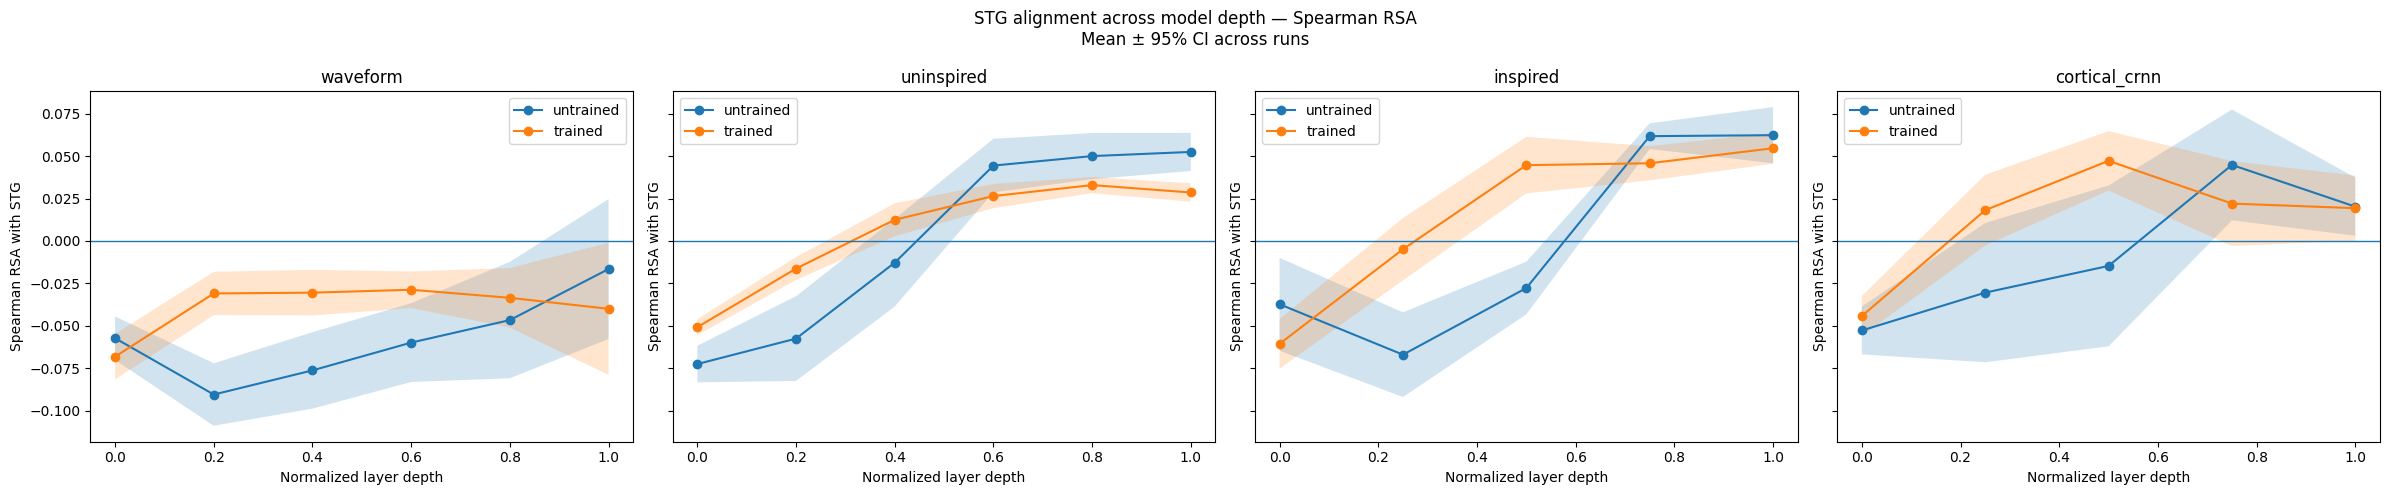

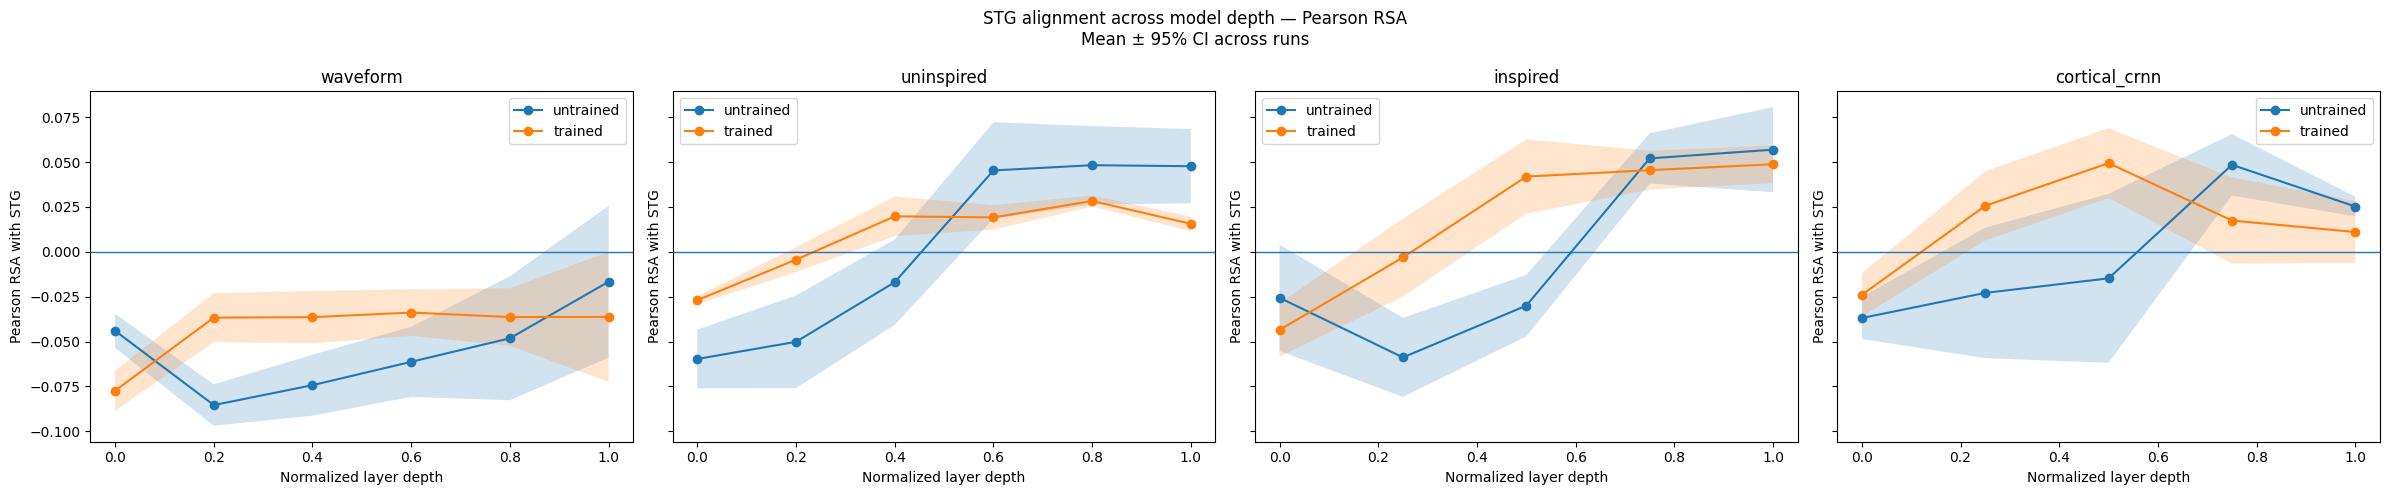

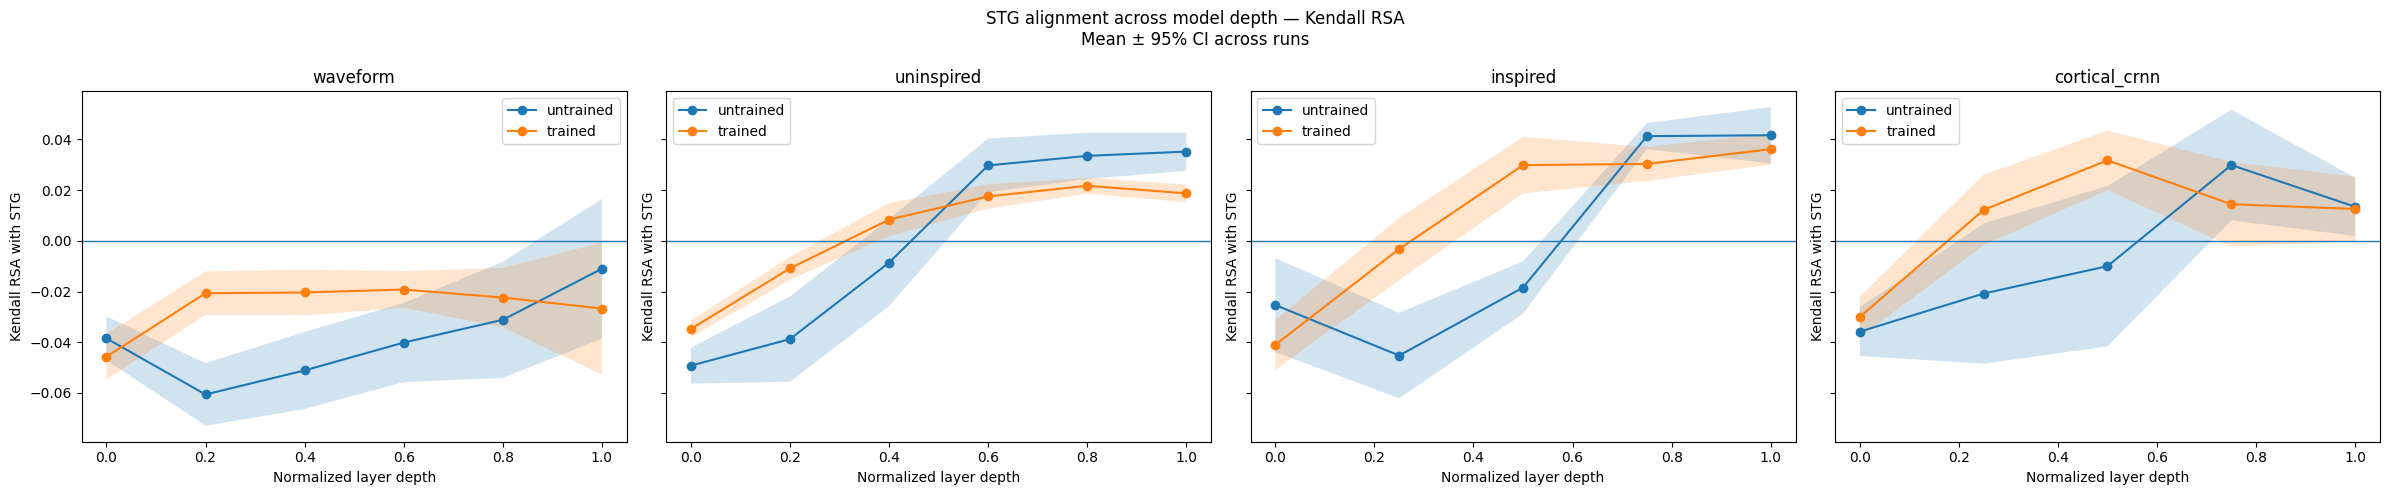

In [12]:

# Mean ± 95% CI across model runs


# preserve the model order defined in model_classes.
provided_models = list(MODEL_CLASSES.keys())

# create one depth-alignment figure for each rsa metric.
for metric in RSA_METRICS:

    fig, axes = plt.subplots(1, len(provided_models), figsize=(6 * len(provided_models), 5), squeeze=False, sharey=True)

    # plot trained and untrained alignment separately for each model.
    for ax, model_name in zip(axes[0], provided_models):

        for condition in ["untrained", "trained"]:

            # select and order the summarized rsa values for the current model and condition.
            data = rsa_df[
                (rsa_df["model"] == model_name)
                & (rsa_df["condition"] == condition)
                & (rsa_df["metric"] == metric)
            ].sort_values("depth")

            # extract normalized depth, mean alignment, and confidence intervals.
            x = data["normalized_depth"].to_numpy()
            y = data["mean"].to_numpy()
            ci = data["ci95"].to_numpy()

            # plot the mean rsa profile across model depth.
            ax.plot(x, y, marker="o", label=condition)

            # add confidence intervals when finite estimates are available.
            finite_ci = np.isfinite(ci)

            if finite_ci.any():
                ax.fill_between(x, y - np.nan_to_num(ci), y + np.nan_to_num(ci), alpha=0.2)

        # add a zero-reference line and panel labels.
        ax.axhline(0, linewidth=1)
        ax.set_xlabel("Normalized layer depth")
        ax.set_ylabel(f"{metric.title()} RSA with STG")
        ax.set_title(model_name)
        ax.legend()

   
    fig.suptitle(f"STG alignment across model depth — {metric.title()} RSA\nMean ± 95% CI across runs")
    fig.tight_layout()

    plt.show()

## Layer depth and STG alignment

The depth plots show a consistent result across Spearman, Pearson, and Kendall RSA: brain alignment changes substantially across model depth, and the shape of this change depends on architecture.

The waveform model remained negatively aligned with STG across almost the entire network. Training improved alignment relative to the untrained condition at most intermediate depths, but the trained curve stayed below zero throughout. The largest improvement occurred in the middle hidden layers, while the final classifier did not show a clear additional gain. This supports the architecture summary: training helps the waveform model relative to its initial state, but does not make its representations positively aligned with STG overall.

The uninspired model showed a much clearer depth-dependent increase. Early convolutional layers were negatively aligned, but alignment became positive around the middle of the network and remained positive in later layers. Training shifted the early and middle representations upward, particularly around normalized depths of 0.2–0.4. However, at later depths the untrained model was numerically above the trained model. 

The inspired model showed a similar but stronger hierarchy. Alignment was negative in the earliest layers, increased substantially through the intermediate convolutional layers, and became clearly positive in the deeper recurrent and output stages. Training produced a large shift upwards in the middle of the network. At later depths, however, the untrained curve again reached values similar to or slightly above the trained curve. This pattern suggests that the architecture itself already imposes a strong late-layer representational structure, while training has its clearest effect on the transition from early to intermediate processing stages.

The CorticalCRNN showed the most distinctive non-monotonic pattern. In the trained condition, STG alignment increased from a negative value at core_conv to positive alignment at belt_conv, then reached its maximum around parabelt_conv at normalized depth 0.5. Alignment then decreased at the recurrent stg_rnn stage and remained lower at the classifier. This pattern was highly similar across all three RSA metrics.

This pattern is especially useful for understanding the custom CorticalCRNN. After training, the early and middle convolutional stages became more similar to the STG responses, with the strongest match appearing around the parabelt-inspired layer. However, this improvement did not continue into the recurrent STG-inspired stage. In other words, some of the similarity gained earlier in the network was reduced after the model started combining information over time.

The untrained CorticalCRNN showed a different pattern. Its early convolutional layers matched the brain poorly, but the recurrent stage showed a much stronger match. After training, the point of strongest brain similarity moved earlier in the network, from the recurrent stage to the parabelt layer. This suggests that training changed where brain-like representations appeared in the network, rather than simply improving every layer equally.

Overall, the three RSA metrics tell the same qualitative story. Spearman, Pearson, and Kendall differ in scale, but all show that the strongest training-related improvements occur mainly in intermediate layers. They also show that deeper is not always more brain-like. For the inspired and uninspired models, alignment tends to rise toward later stages, whereas for CorticalCRNN the best correspondence appears at an intermediate convolutional stage and decreases after the recurrent layer.


In [13]:

# DEPTH ANALYSIS


# store one row per independent run and rsa metric.
depth_rows = []

# measure the monotonic relationship between layer depth and brain alignment.
for (condition, model_name, run_id, metric), group in rsa_run_df.groupby(["condition", "model", "run", "metric"], sort=False):

    # order layers by depth before computing the correlation.
    group = group.sort_values("depth")

    # skip models with too few layers for a meaningful depth analysis.
    if len(group) < 3:
        continue

    # compute spearman correlation between normalized depth and brain alignment.
    rho, p_value = spearmanr(group["normalized_depth"], group["brain_alignment"])

    # store the run-level depth correlation and corresponding p-value.
    depth_rows.append({
        "condition": condition,
        "model": model_name,
        "run": run_id,
        "metric": metric,
        "depth_alignment_rho": rho,
        "p_value": p_value,
        "n_layers": len(group),
    })

# convert run-level depth statistics to a dataframe.
depth_run_df = pd.DataFrame(depth_rows)

# summarize depth correlations across runs using the mean and 95% confidence interval.
depth_analysis_df = summarize_with_ci(
    depth_run_df,
    group_columns=["condition", "model", "metric"],
    value_column="depth_alignment_rho",
)

# report on the relationship between model depth and brain alignment.
print("\nRelationship between depth and brain alignment")
print(depth_analysis_df.sort_values(["metric", "condition", "model"]).to_string(index=False))



Relationship between depth and brain alignment
 condition         model   metric     mean     ci95    ci_low  ci_high  n_runs
pretrained        yamnet  kendall 0.610714      NaN       NaN      NaN       1
   trained cortical_crnn  kendall 0.400000 0.297249  0.102751 0.697249       5
   trained      inspired  kendall 0.900000 0.107354  0.792646 1.007354       5
   trained    uninspired  kendall 0.885714 0.050088  0.835626 0.935802       5
   trained      waveform  kendall 0.314286 0.498369 -0.184083 0.812654       5
 untrained cortical_crnn  kendall 0.720000 0.096020  0.623980 0.816020       5
 untrained      inspired  kendall 0.840000 0.099941  0.740059 0.939941       5
 untrained    uninspired  kendall 0.920000 0.097639  0.822361 1.017639       5
 untrained      waveform  kendall 0.565714 0.309979  0.255735 0.875693       5
pretrained        yamnet  pearson 0.453571      NaN       NaN      NaN       1
   trained cortical_crnn  pearson 0.140000 0.466299 -0.326299 0.606299       5
   t

## Relationship between model depth and STG alignment

The correlation between normalized layer depth and STG alignment was generally positive, but its strength differed substantially across architectures.

For the trained inspired model, the relationship was very strong and consistent across RSA metrics. Spearman and Kendall both gave a mean depth–alignment correlation of 0.90 with a 95% CI of approximately [0.79, 1.01], while Pearson gave the same mean of 0.90. This indicates that, for this architecture, later layers were consistently more STG-aligned than earlier layers.

The trained uninspired model showed a similarly strong positive relationship. Spearman and Kendall gave a mean correlation of 0.886 with a 95% CI of [0.836, 0.936], while Pearson gave 0.726 [0.636, 0.815]. This again suggests a clear increase in STG alignment with depth, although the Pearson result was somewhat weaker than the rank-based metrics.

The trained CorticalCRNN showed a weaker and less uniform depth relationship. Spearman and Kendall both gave a mean correlation of 0.40 [0.103, 0.697], while Pearson was only 0.14 with a wide CI spanning zero, [−0.326, 0.606]. This weaker monotonic relationship is consistent with the layer-wise plots: alignment improves from the early convolutional stages toward `parabelt_conv`, but then drops again at the recurrent and classification stages. In other words, deeper layers are not consistently more brain-like in CorticalCRNN.

The trained waveform model showed the least stable pattern. Spearman and Kendall gave a mean correlation of 0.314 with a very wide CI crossing zero, [−0.184, 0.813], while Pearson gave 0.497 [0.043, 0.951]. This suggests that some runs showed increasing alignment with depth, but the effect was not consistent across all runs.

The untrained models also showed positive depth relationships. In fact, these were sometimes stronger than in the trained versions. For example, untrained CorticalCRNN had a Spearman/Kendall correlation of 0.72 [0.624, 0.816], compared with 0.40 after training. The untrained uninspired model reached 0.92 [0.822, 1.018], and the untrained inspired model reached 0.84 [0.740, 0.940]. This shows that a positive depth gradient is partly an architectural property and is not created solely by training.

For YAMNet, the depth relationship was also positive: approximately 0.61available, no confidence interval could be estimated.

### Interpretation

The main conclusion is that depth often increases STG alignment, but not in a universal or purely linear way.

For the inspired and uninspired architectures, deeper processing stages are strongly associated with greater brain alignment. For CorticalCRNN, however, the relationship is weaker because alignment peaks at an intermediate stage and then declines. The results suggest that the type of transformation performed at a layer matters more than depth alone.

The stronger depth correlations in some untrained models also show that architecture itself can impose a representational progression before learning. Training modifies this progression rather than simply making every deeper layer more brain-like.

One technical caution is that some confidence intervals extend slightly above 1.0. Because a correlation cannot exceed 1, these upper bounds should not be interpreted literally. They arise from applying a conventional mean ± 95% CI calculation to bounded correlation coefficients near the upper limit.

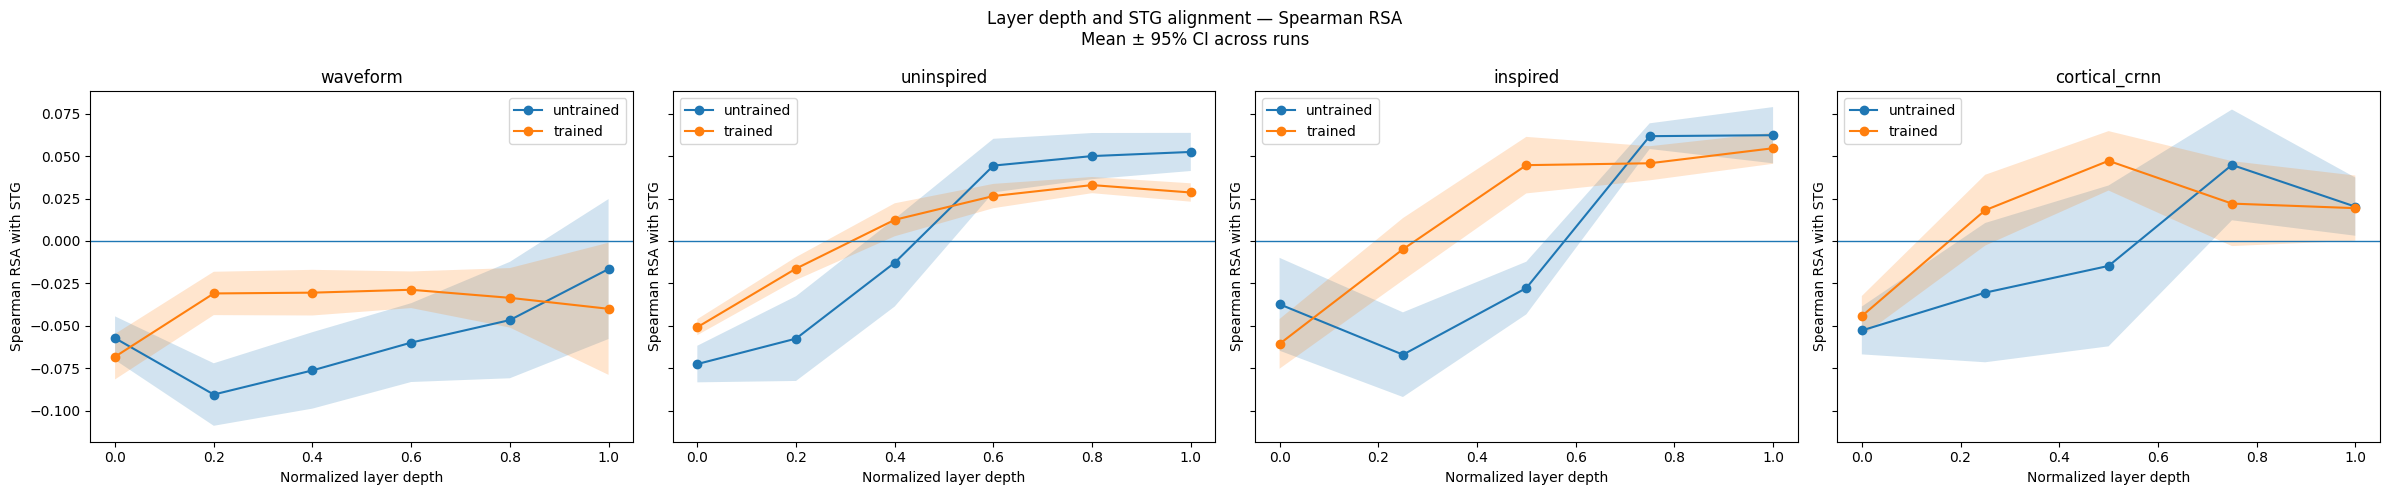

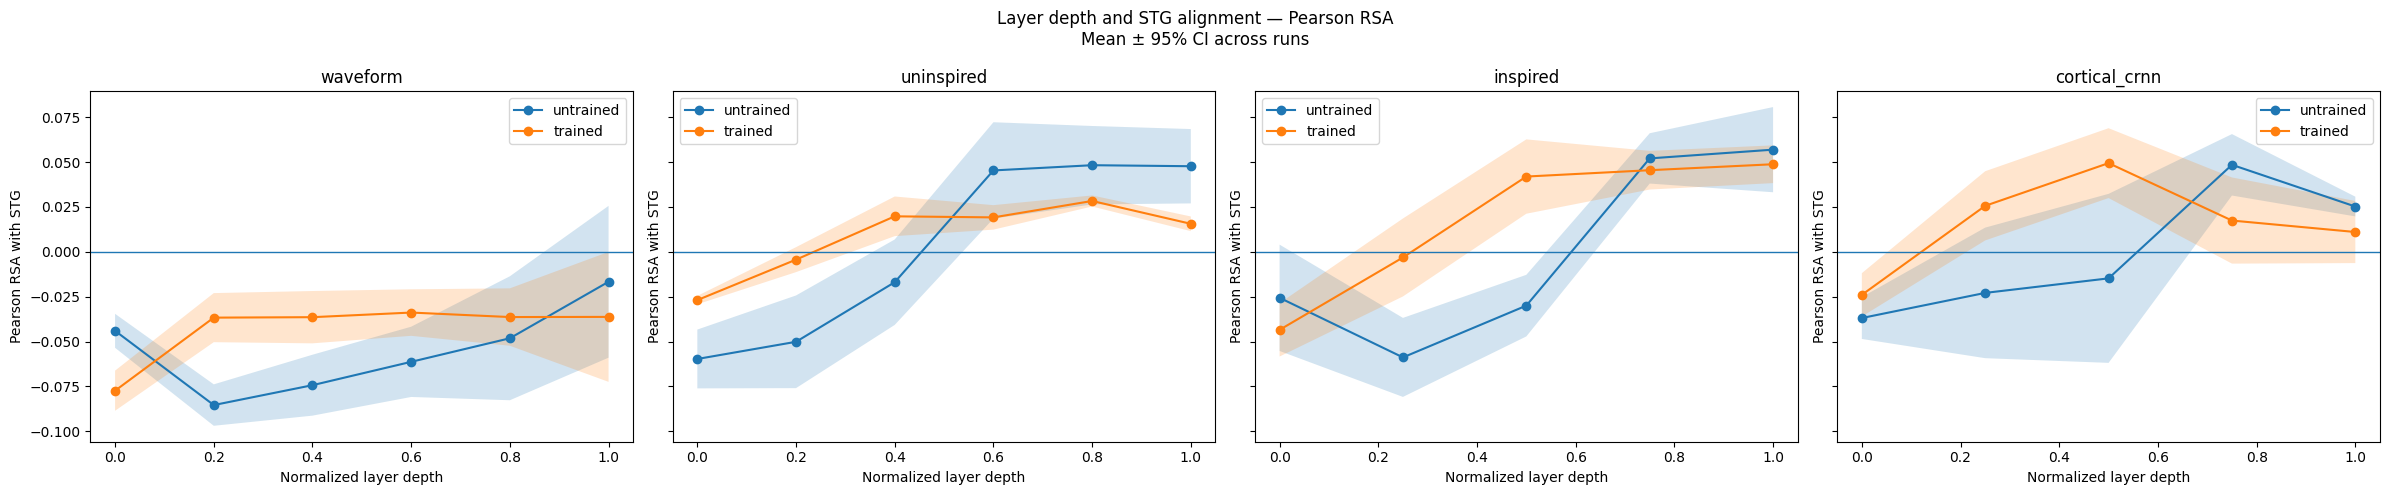

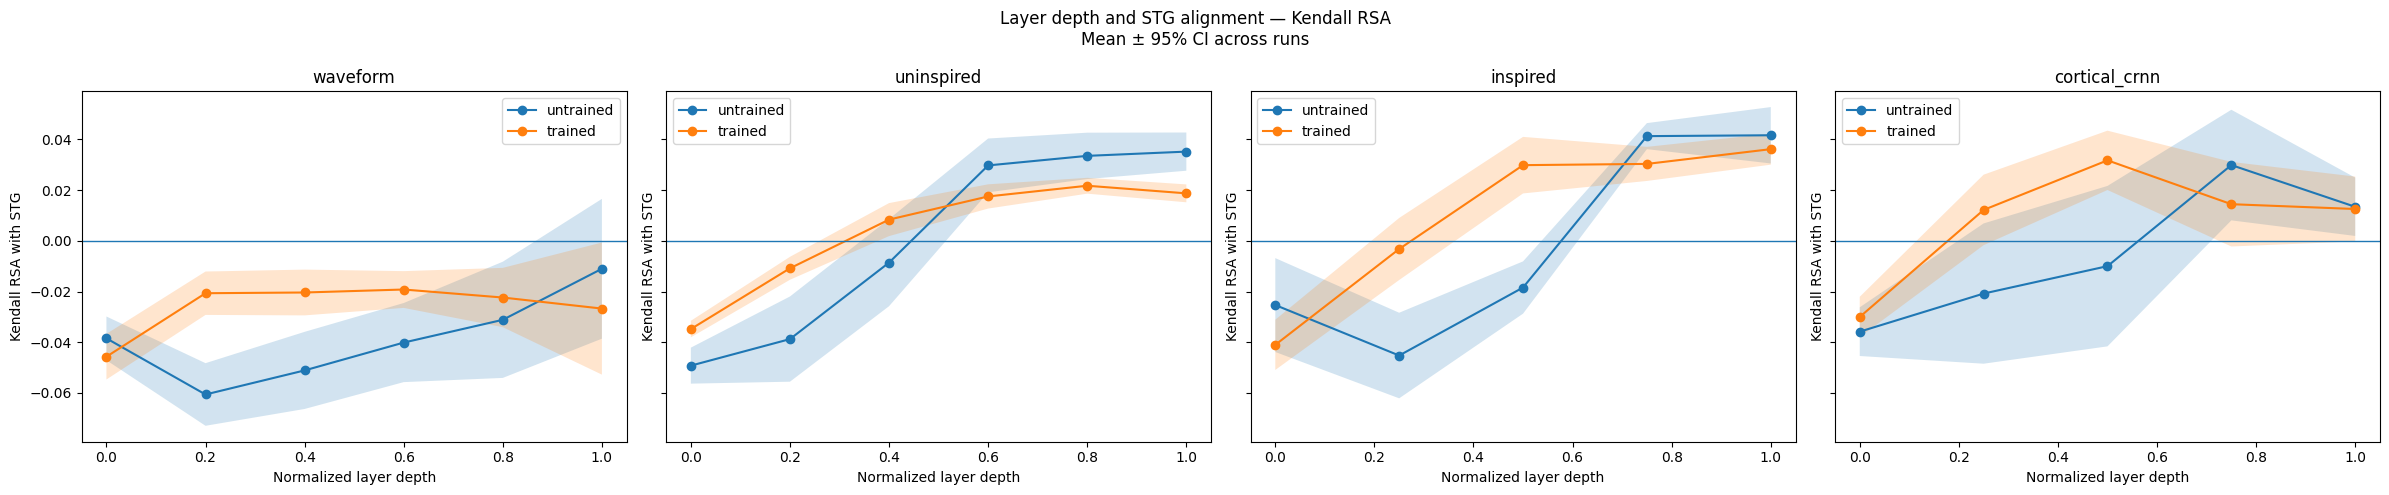

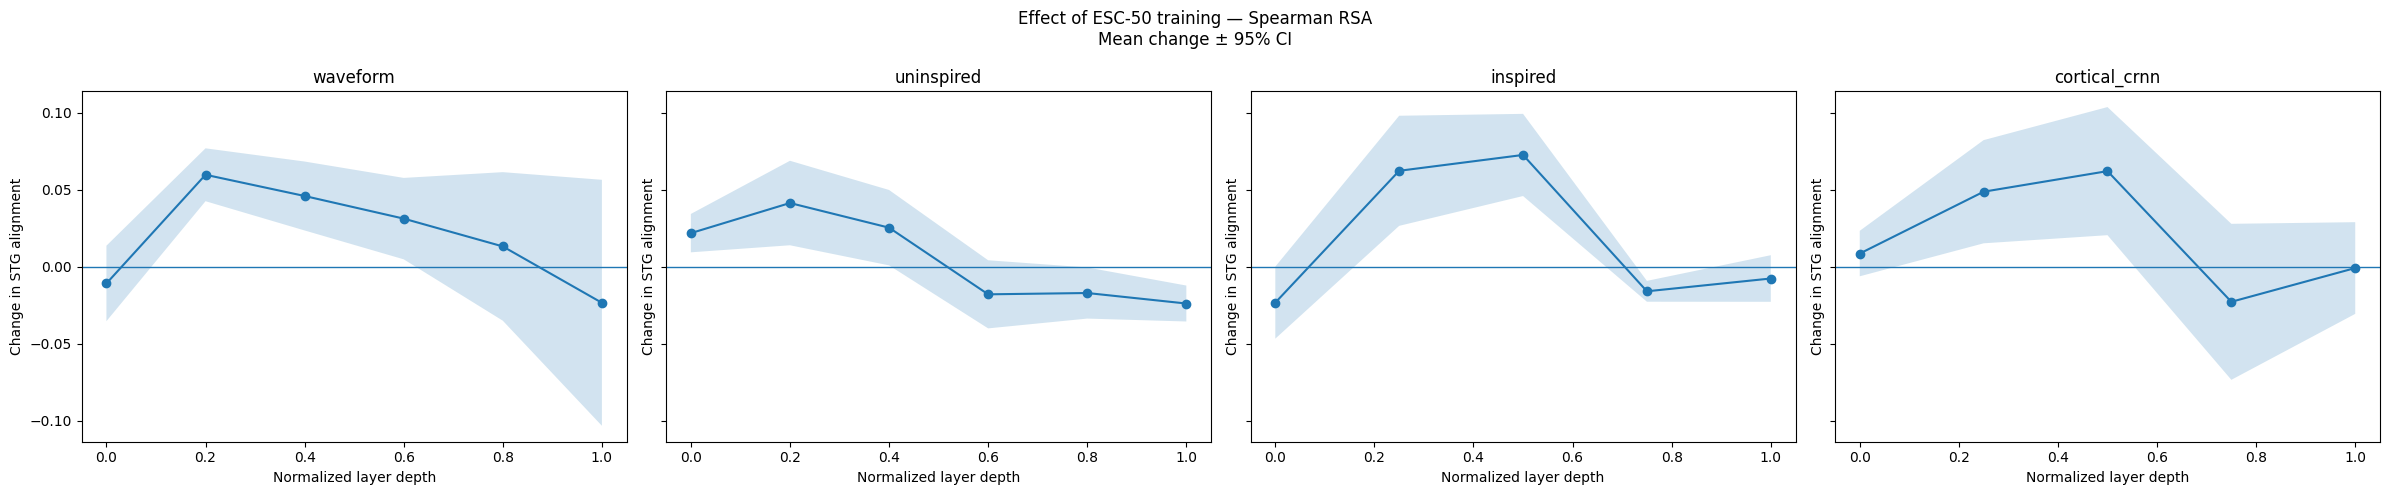

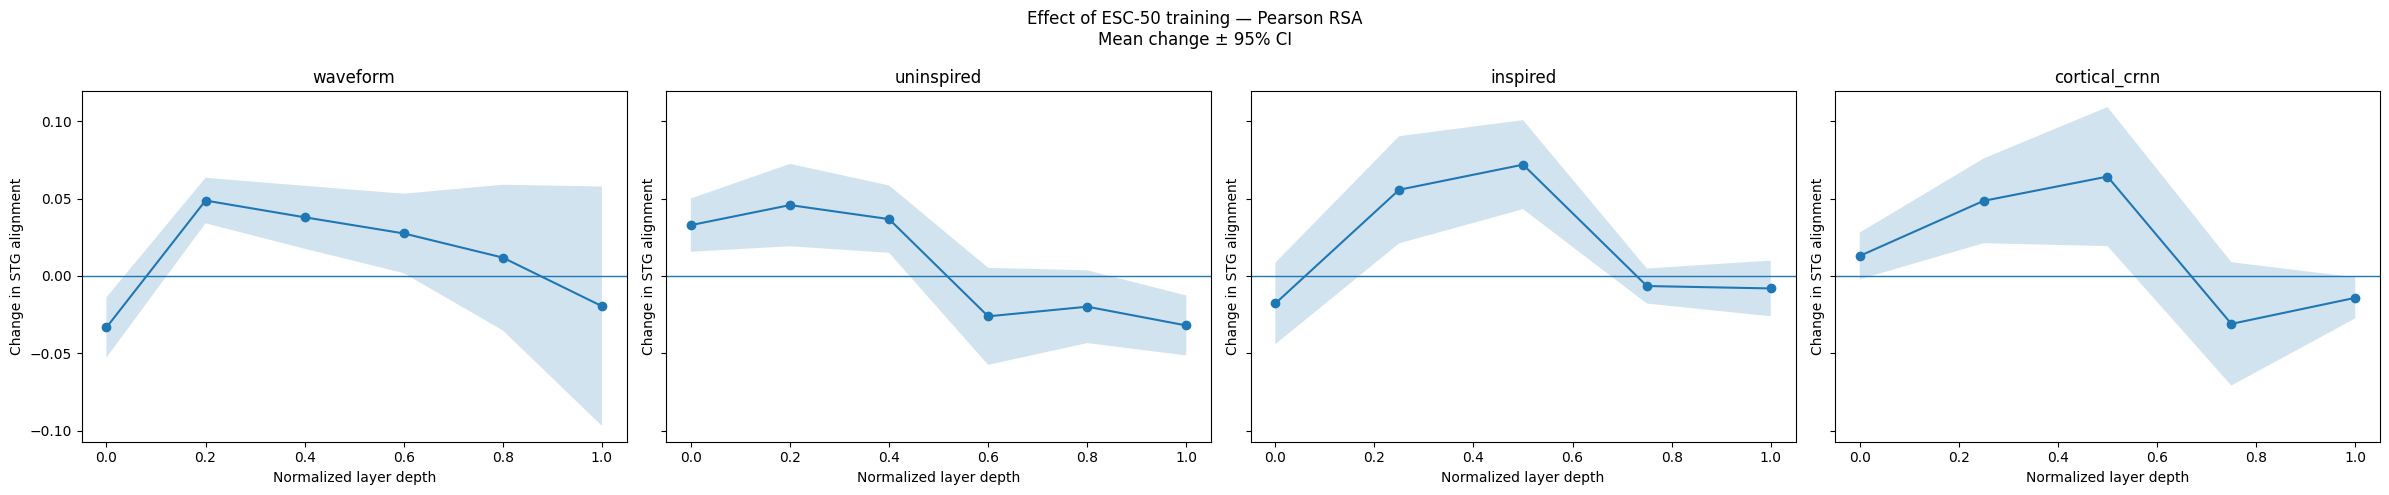

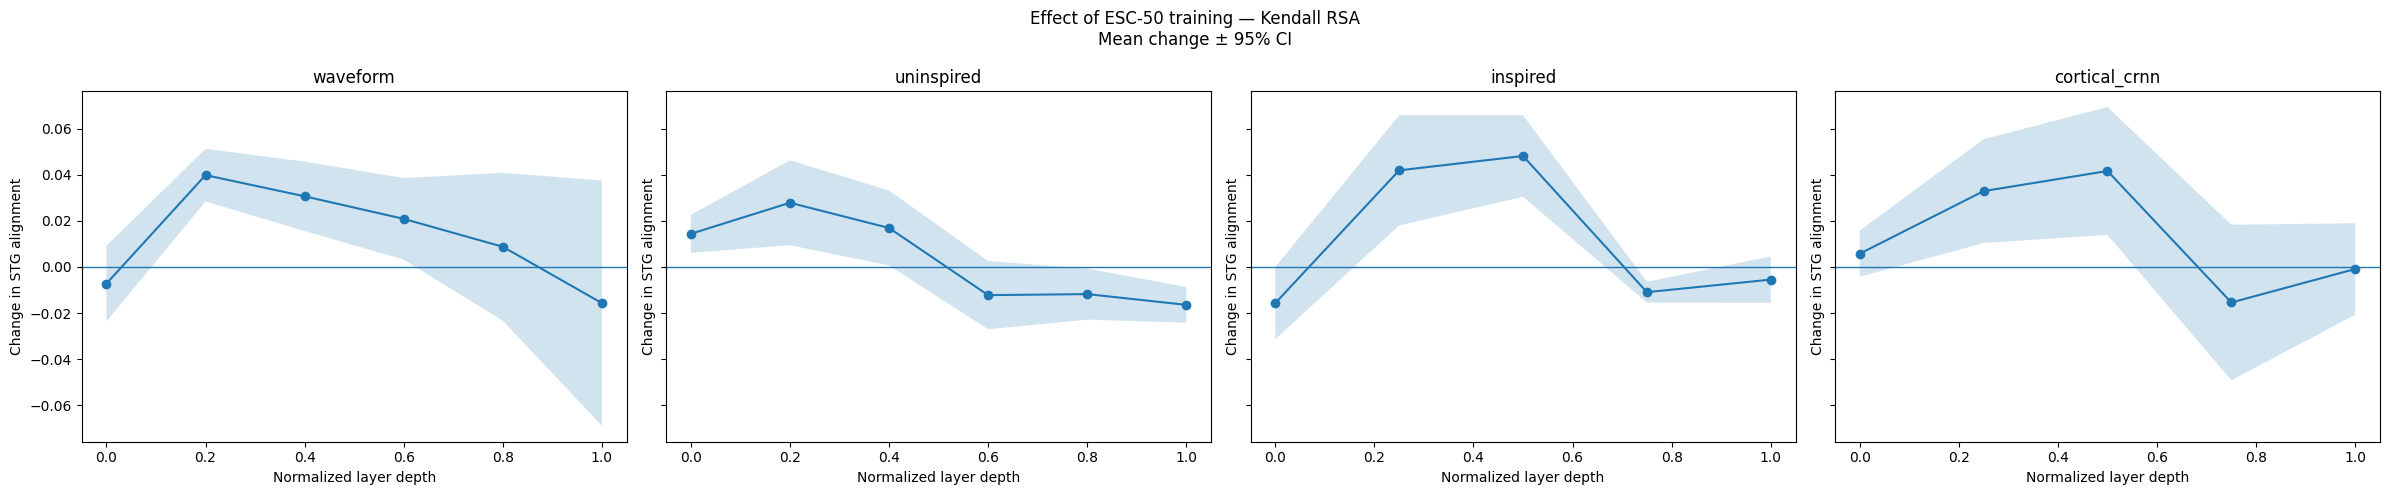

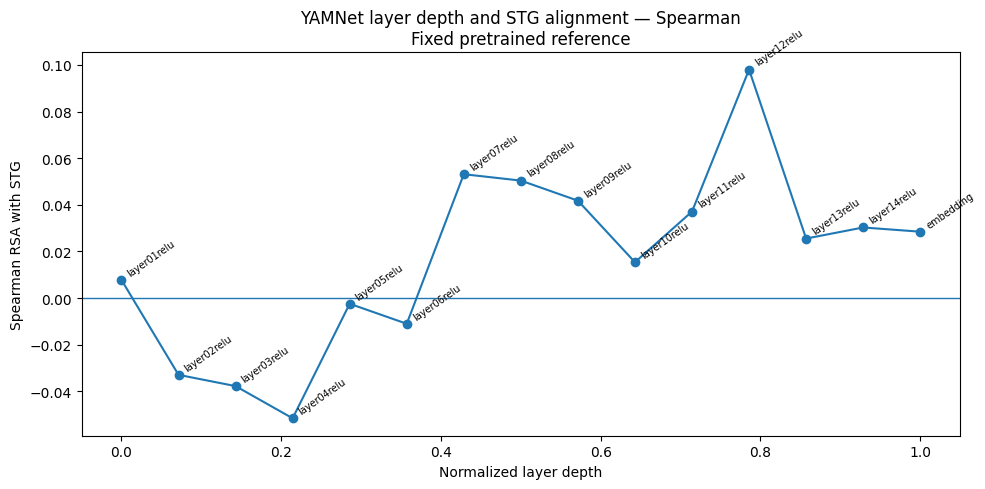

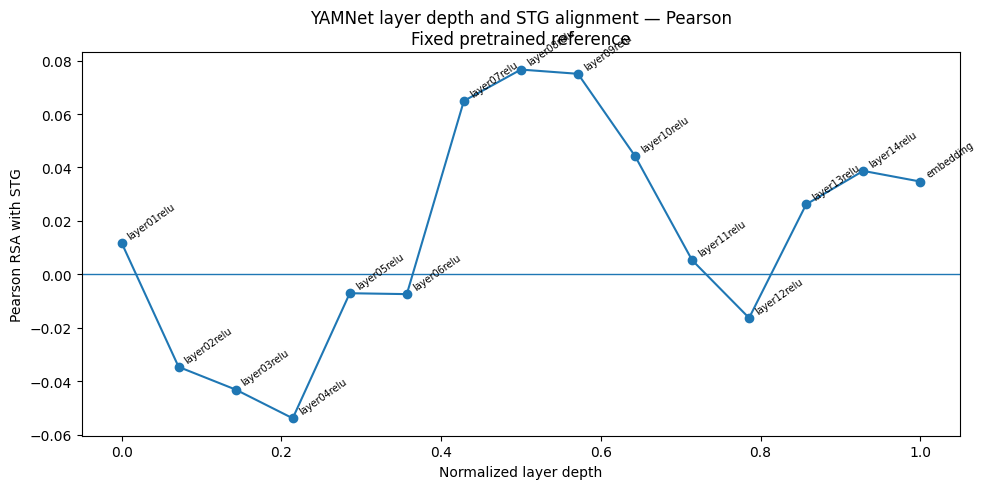

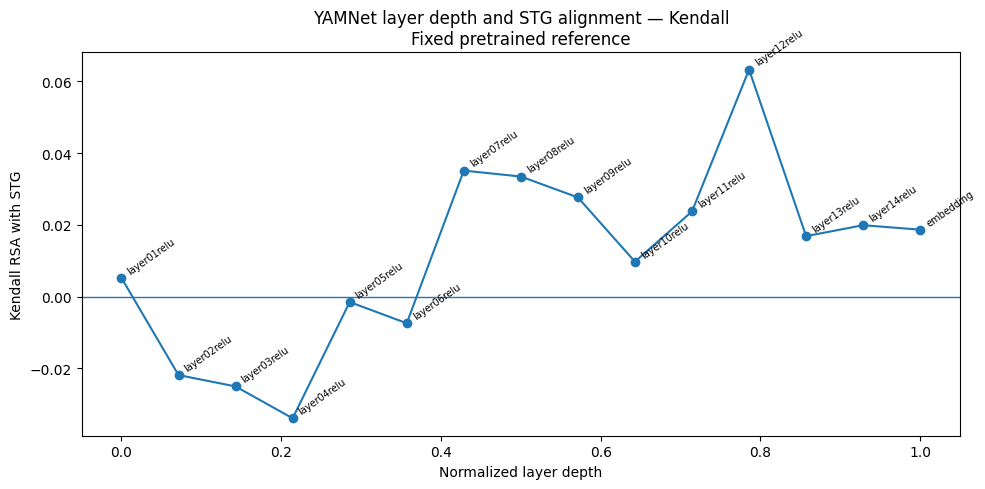

In [14]:
# PLOT: STG ALIGNMENT VS MODEL DEPTH


# preserve the model order defined in model_classes.
provided_models = list(MODEL_CLASSES.keys())

# plot mean stg alignment across normalized layer depth for each rsa metric.
for metric in RSA_METRICS:

    fig, axes = plt.subplots(1, len(provided_models), figsize=(6 * len(provided_models), 5), squeeze=False, sharey=True)

    # create one panel per model architecture.
    for ax, model_name in zip(axes[0], provided_models):

        # plot untrained and trained representations separately.
        for condition in ["untrained", "trained"]:

            # select summarized rsa values for the current model, condition, and metric.
            data = rsa_df[
                (rsa_df["model"] == model_name)
                & (rsa_df["condition"] == condition)
                & (rsa_df["metric"] == metric)
            ].sort_values("depth")

            # extract normalized depth, mean alignment, and confidence intervals.
            x = data["normalized_depth"].to_numpy()
            y = data["mean"].to_numpy()
            ci = data["ci95"].to_numpy()

            # plot the mean alignment profile across model depth.
            ax.plot(x, y, marker="o", label=condition)

            # add confidence intervals when finite estimates are available.
            if len(ci) > 0 and np.isfinite(ci).any():
                ax.fill_between(x, y - np.nan_to_num(ci), y + np.nan_to_num(ci), alpha=0.2)

        # add panel labels, a zero-reference line plus legend.
        ax.axhline(0, linewidth=1)
        ax.set_xlabel("Normalized layer depth")
        ax.set_ylabel(f"{metric.title()} RSA with STG")
        ax.set_title(model_name)
        ax.legend()

    
    fig.suptitle(f"Layer depth and STG alignment — {metric.title()} RSA\nMean ± 95% CI across runs")
    fig.tight_layout()

    
    plt.show()



# PLOT: TRAINING EFFECT

# plot the change in stg alignment caused by esc-50 training.
for metric in RSA_METRICS:

    fig, axes = plt.subplots(1, len(provided_models), figsize=(6 * len(provided_models), 5), squeeze=False, sharey=True)

    # create one panel per model architecture.
    for ax, model_name in zip(axes[0], provided_models):

        # select summarized training effects for the current model and metric.
        data = training_effect_df[
            (training_effect_df["model"] == model_name)
            & (training_effect_df["metric"] == metric)
        ].sort_values("depth")

        # extract normalized depth, mean training effect, and confidence intervals.
        x = data["normalized_depth"].to_numpy()
        y = data["mean"].to_numpy()
        ci = data["ci95"].to_numpy()

        # plot the mean change in brain alignment across model depth.
        ax.plot(x, y, marker="o")

        # add confidence intervals when finite estimates are available.
        if len(ci) > 0 and np.isfinite(ci).any():
            ax.fill_between(x, y - np.nan_to_num(ci), y + np.nan_to_num(ci), alpha=0.2)

        # add panel labels and a zero-reference line.
        ax.axhline(0, linewidth=1)
        ax.set_xlabel("Normalized layer depth")
        ax.set_ylabel("Change in STG alignment")
        ax.set_title(model_name)


    fig.suptitle(f"Effect of ESC-50 training — {metric.title()} RSA\nMean change ± 95% CI")
    fig.tight_layout()

    
    plt.show()


# YAMNET DEPTH


# plot yamnet separately because it is one fixed pretrained reference without across-run confidence intervals.
for metric in RSA_METRICS:

    # select and order yamnet rsa scores for the current metric.
    yamnet_scores = rsa_run_df[
        (rsa_run_df["model"] == "yamnet")
        & (rsa_run_df["metric"] == metric)
    ].sort_values("depth")

    # create the yamnet depth-alignment figure.
    plt.figure(figsize=(10, 5))
    plt.plot(yamnet_scores["normalized_depth"], yamnet_scores["brain_alignment"], marker="o")

    # label each point with its corresponding yamnet layer.
    for _, row in yamnet_scores.iterrows():
        plt.annotate(row["layer"], (row["normalized_depth"], row["brain_alignment"]), fontsize=7, rotation=35, xytext=(3, 3), textcoords="offset points")

    # add axis labels, a title, and a zero-reference line.
    plt.xlabel("Normalized layer depth")
    plt.ylabel(f"{metric.title()} RSA with STG")
    plt.title(f"YAMNet layer depth and STG alignment — {metric.title()}\nFixed pretrained reference")
    plt.axhline(0, linewidth=1)
    plt.tight_layout()

    plt.show()


## Effect of ESC-50 training across model depth

The training-effect plots make the layer-specific pattern more explicit. The figures show the change in STG alignment caused by training at each depth, with values above zero indicating improved alignment after ESC-50 training.

Across Spearman, Pearson, and Kendall RSA, the same broad pattern appears: training mainly benefits intermediate layers, while the final stages show little improvement or even a decrease.
These results suggest that ESC-50 training does not make the entire network uniformly more brain-like. Its strongest and most reliable effect is on intermediate feature representations.

This pattern appears across multiple architectures. The convolutional and hidden layers seem to learn auditory structure that becomes more compatible with STG representational geometry, while later recurrent, fully connected, or classifier stages increasingly reflect the demands of the ESC-50 classification task.

For the custom CorticalCRNN, this means the strongest support is for the core–belt–parabelt style convolutional hierarchy, especially the belt and parabelt stages. The current recurrent implementation is less strongly supported by the RSA results, since it does not preserve the training-related improvement seen immediately before it.

Taken together with the depth plots, the main conclusion is that training and depth interact rather than acting independently. Deeper is not automatically better, and the most brain-aligned stage is often an intermediate representation rather than the final model output.

## YAMNet depth profile

YAMNet shows a clear but non-monotonic relationship between layer depth and STG alignment. Across Spearman, Pearson, and Kendall RSA, the earliest layers are weakly or negatively aligned, while several intermediate and later layers become positively aligned.

The clearest increase begins around the middle of the network. Under Pearson RSA, alignment rises sharply from negative values in the early layers to around 0.065–0.077 across `layer07relu` to `layer09relu`, with the highest value at `layer08relu` (approximately 0.077). Under Spearman RSA, the largest peak occurs later, at `layer12relu`, reaching approximately 0.098. Kendall shows the same late peak at `layer12relu`, at approximately 0.063.

The final embedding is positive but does not produce the strongest alignment. This is important because it shows that the most task-abstract YAMNet representation is not necessarily the most STG-like. Instead, the best correspondence appears within internal hidden layers.

Overall, YAMNet supports the same general conclusion seen in the other models: brain alignment is strongly layer-specific and does not simply increase toward the final output. Intermediate or late hidden representations can align more closely with STG than the final embedding.


In [15]:
# CATEGORY SEPARABILITY


# extract category labels for all santoro sounds.
categories = np.asarray(santoro_dataset.categories)

# convert category names to integer labels required by silhouette_score.
unique_categories, category_labels = np.unique(categories, return_inverse=True)

# compute category separability directly in the stg representational space.
brain_category_silhouette = silhouette_score(clean_rdm(brain_rdm), category_labels, metric="precomputed")

# report the stg category silhouette score.
print("\nSTG category silhouette:", brain_category_silhouette)

# store one row per model, run, and layer.
category_rows = []

# compute category separability for untrained and trained model representations.
for condition, model_rdms in [("untrained", untrained_rdms), ("trained", trained_rdms)]:

    for model_name, runs in model_rdms.items():

        for run_id, layer_rdms in runs.items():

            # preserve layer order for depth analysis.
            layer_names = list(layer_rdms.keys())
            n_layers = len(layer_names)

            # compute category separability at every model depth.
            for depth, layer_name in enumerate(layer_names):

                normalized_depth = depth / (n_layers - 1) if n_layers > 1 else 0
                score = silhouette_score(clean_rdm(layer_rdms[layer_name]), category_labels, metric="precomputed")

                category_rows.append({
                    "condition": condition,
                    "model": model_name,
                    "run": run_id,
                    "layer": layer_name,
                    "depth": depth,
                    "normalized_depth": normalized_depth,
                    "silhouette": score,
                })


# compute category separability for the fixed pretrained yamnet reference.
for depth, layer_name in enumerate(yamnet_layer_names):

    # normalize yamnet depth to the same 0-1 range used for the other models.
    normalized_depth = depth / (len(yamnet_layer_names) - 1) if len(yamnet_layer_names) > 1 else 0

    # compute the silhouette score from the layer rdm.
    score = silhouette_score(clean_rdm(yamnet_rdms[layer_name]), category_labels, metric="precomputed")

    category_rows.append({
        "condition": "pretrained",
        "model": "yamnet",
        "run": -1,
        "layer": layer_name,
        "depth": depth,
        "normalized_depth": normalized_depth,
        "silhouette": score,
    })

# convert run-level category separability results to a dataframe.
category_run_df = pd.DataFrame(category_rows)

# summarize category separability across runs using the mean and 95% confidence interval.
category_separability_df = summarize_with_ci(
    category_run_df,
    group_columns=["condition", "model", "layer", "depth", "normalized_depth"],
    value_column="silhouette",
)

print("\nCategory separability (mean ± 95% CI)")
print(category_separability_df.sort_values(["model", "condition", "depth"]).to_string(index=False))


STG category silhouette: -0.2024255479993184

Category separability (mean ± 95% CI)
 condition         model           layer  depth  normalized_depth      mean     ci95    ci_low   ci_high  n_runs
   trained cortical_crnn       core_conv      0          0.000000 -0.119629 0.009438 -0.129068 -0.110191       5
   trained cortical_crnn       belt_conv      1          0.250000 -0.126650 0.006065 -0.132715 -0.120584       5
   trained cortical_crnn   parabelt_conv      2          0.500000 -0.162171 0.011003 -0.173174 -0.151168       5
   trained cortical_crnn         stg_rnn      3          0.750000 -0.357013 0.025960 -0.382973 -0.331053       5
   trained cortical_crnn      classifier      4          1.000000 -0.488422 0.024117 -0.512539 -0.464304       5
 untrained cortical_crnn       core_conv      0          0.000000 -0.176331 0.042015 -0.218346 -0.134316       5
 untrained cortical_crnn       belt_conv      1          0.250000 -0.171725 0.039350 -0.211075 -0.132376       5
 untrained 

## Category separability

Category structure was quantified using the silhouette score, where higher values indicate that samples from the same category cluster more clearly than samples from different categories. The STG data had a silhouette score of **−0.202**, indicating that the ESC-50 category labels do not form cleanly separated clusters in the measured brain representation.

This is an important reference point. A model does not become more brain-like simply by obtaining a higher silhouette score, because the STG itself does not show strong category clustering under this measure. Instead, the silhouette analysis describes how explicitly each representation organizes the stimuli according to the task categories.

### CorticalCRNN

For the trained CorticalCRNN, category separation was strongest in the early and intermediate convolutional stages. The mean silhouette scores were **−0.120** for `core_conv`, **−0.127** for `belt_conv`, and **−0.162** for `parabelt_conv`. All three were less negative than the STG value of −0.202, meaning that these layers showed somewhat clearer category organization than the brain data.

After the convolutional hierarchy, however, the silhouette score dropped sharply to **−0.357** in `stg_rnn` and **−0.488** in the classifier. Thus, the later recurrent and output representations showed substantially more overlap between categories.

Training also changed the category structure differently across layers. In `core_conv` and `belt_conv`, training improved separability relative to the untrained condition. For example, `core_conv` changed from **−0.176** untrained to **−0.120** trained, and `belt_conv` from **−0.172** to **−0.127**. At `parabelt_conv`, the trained and untrained values were similar. In contrast, the trained `stg_rnn` was more negative than the untrained version, while the trained classifier was slightly less negative than the untrained classifier.

This suggests that training sharpened category structure mainly in the early convolutional hierarchy, while the recurrent stage did not preserve this benefit.

### Inspired model

The inspired model showed a very similar pattern. Its trained convolutional layers had silhouette scores of approximately **−0.131**, **−0.120**, and **−0.140**, all less negative than the STG reference. The recurrent layer then dropped to **−0.300**, and the classifier to **−0.399**.

Compared with the untrained model, training improved category separability in all three convolutional layers and also made the recurrent and classifier representations somewhat less negative. Nevertheless, the largest decrease in separability still occurred after the convolutional stages.

This again suggests that the convolutional hierarchy contains the clearest task-category structure, whereas the recurrent and output stages produce a more mixed representational geometry.

### Uninspired model

The uninspired model also showed relatively moderate negative silhouette scores in its convolutional layers, ranging from approximately **−0.129 to −0.152** after training. However, there was a pronounced drop when the representation entered the fully connected part of the network: `fc_layers.0` reached **−0.477**, `fc_layers.1` **−0.469**, and the classifier **−0.550**.

Training improved separability in the convolutional layers compared with the untrained model, but the later fully connected representations became more negative. In particular, the trained classifier was considerably lower than the untrained classifier, changing from approximately **−0.466** to **−0.550**.

The result indicates a clear distinction between the convolutional feature space and the later task-specific representation.

### Waveform model

The waveform model behaved very differently from the other architectures. Its trained representations showed strongly negative silhouette scores at every depth, beginning at **−0.587** in the first hidden layer and decreasing further to **−0.790** at the classifier.

The untrained waveform model was substantially less negative, ranging from approximately **−0.188** in the first layer to **−0.458** at the classifier. Training therefore made the category silhouette markedly more negative throughout this architecture.

This result may seem counterintuitive for a classification model, but silhouette score measures whether categories form compact and separated clusters under the chosen distance measure. A representation can still support classification without arranging samples into compact clusters. The waveform model therefore appears to solve the task using a representational geometry that is poorly described by simple category clustering.

### YAMNet

YAMNet showed a distinct progression across depth. Its early layers started with negative silhouette values close to the STG range, such as **−0.181** at `layer01relu`, and became progressively less negative through the middle of the network.

The highest separability occurred around `layer10relu`, where the silhouette score reached approximately **0.001**, effectively zero. This indicates that the middle YAMNet representation was much closer to neutral category separation than the STG representation.

After this point, the scores became more negative again. `layer12relu` had a silhouette score of **−0.206**, which is numerically very close to the STG value of −0.202, followed by **−0.269** at `layer13relu`, **−0.353** at `layer14relu`, and **−0.327** in the final embedding.

Thus, YAMNet also shows that category structure changes non-monotonically across depth rather than steadily becoming more separated.

## Interpretation

The main result is that **category separability and model depth are not related in a simple way**.

Across CorticalCRNN, inspired, and uninspired models, the early and intermediate convolutional layers generally showed the clearest category organization. Later recurrent, fully connected, or classifier stages often had substantially more negative silhouette scores.

This is important because it shows that later task representations should not automatically be interpreted as cleaner category spaces. Training can make a representation more useful for classification without forcing each category into a compact cluster under correlation distance.

The STG result is also important for interpretation. Because the brain silhouette score itself was negative, the neural representation does not appear to organize these sounds primarily as clean ESC-50 category clusters. Therefore, a model with a silhouette score closer to zero or even positive is not necessarily more brain-like. The silhouette analysis should instead be treated as a complementary measure of **category organization**, while RSA directly measures similarity to STG representational structure.

Overall, the category analysis suggests that the strongest task-category structure is generally found in intermediate feature representations, while later stages reorganize the information in a way that is less well described by compact category clusters.

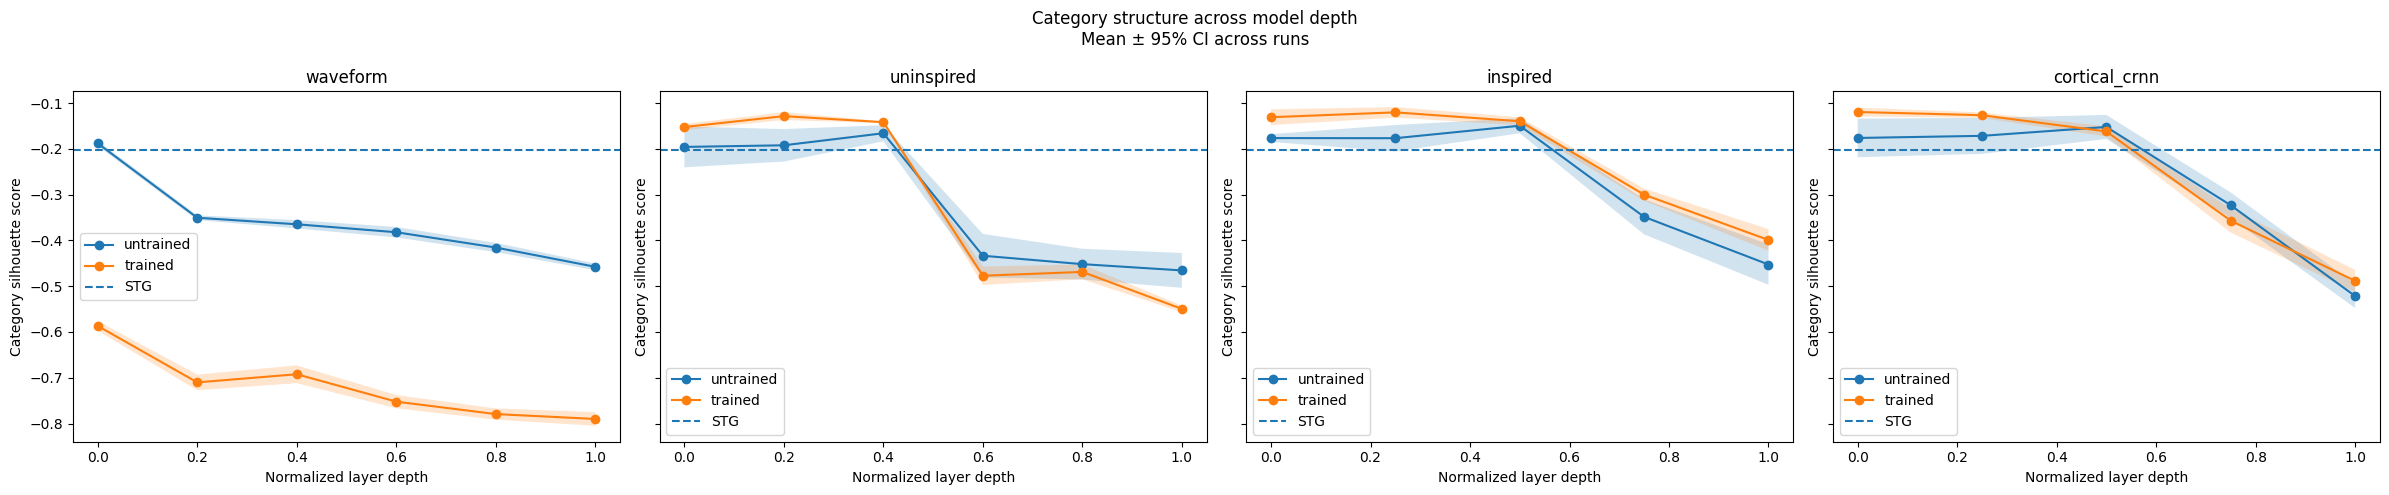

In [16]:
# PLOT: CATEGORY SEPARABILITY VS DEPTH


# create one panel per provided model and share the y-axis across panels.
fig, axes = plt.subplots(1, len(provided_models), figsize=(6 * len(provided_models), 5), squeeze=False, sharey=True)

# plot category separability across layer depth for each model.
for ax, model_name in zip(axes[0], provided_models):

    # plot untrained and trained models separately.
    for condition in ["untrained", "trained"]:

        # select summarized category separability values for the current model and condition.
        data = category_separability_df[
            (category_separability_df["model"] == model_name)
            & (category_separability_df["condition"] == condition)
        ].sort_values("depth")

        # extract normalized depth, mean silhouette, and confidence intervals.
        x = data["normalized_depth"].to_numpy()
        y = data["mean"].to_numpy()
        ci = data["ci95"].to_numpy()

        # plot the mean category separability profile across model depth.
        ax.plot(x, y, marker="o", label=condition)

        # add confidence intervals when finite estimates are available.
        if len(ci) > 0 and np.isfinite(ci).any():
            ax.fill_between(x, y - np.nan_to_num(ci), y + np.nan_to_num(ci), alpha=0.2)

    # add the stg reference line and panel labels.
    ax.axhline(brain_category_silhouette, linestyle="--", label="STG")
    ax.set_xlabel("Normalized layer depth")
    ax.set_ylabel("Category silhouette score")
    ax.set_title(model_name)
    ax.legend()


fig.suptitle("Category structure across model depth\nMean ± 95% CI across runs")
fig.tight_layout()


plt.show()

## Category structure across model depth

The category-structure plot makes the earlier silhouette results easier to interpret because it shows how category separability changes across depth relative to the STG reference line at approximately −0.202.

The waveform model is clearly separated from the other architectures. Its untrained first layer starts close to the STG value, but separability becomes progressively more negative with depth. Training shifts the entire curve much further downward, from roughly −0.59 in the first trained layer to almost −0.79 at the classifier. This indicates that ESC-50 training strongly reorganizes the waveform representation, but not into compact category clusters under this silhouette measure.

The uninspired model shows relatively good category separability in its convolutional layers. Both trained and untrained curves remain close to, or less negative than, the STG reference through the first three layers. A sharp drop occurs when the model enters the fully connected layers, where silhouette scores fall to around −0.45 to −0.55. Training improves the early convolutional representations but does not prevent this loss of category structure in later stages.

The inspired model shows a similar, but a bit smoother transition . Its convolutional layers remain around −0.12 to −0.15, clearly less negative than the STG reference. Then category separability declines in the recurrent layer and classifier. Compared with the untrained model, training generally makes the curve less negative, especially in the early and middle stages, suggesting that the learned convolutional hierarchy produces more organized category structure.

The CorticalCRNN again follows a comparable pattern. The trained `core_conv`, `belt_conv`, and `parabelt_conv` stages all remain above the STG reference line, with silhouette scores around −0.12 to −0.16. After this point, there is a strong drop at `stg_rnn` and a further decline at the classifier. Training improves the first two convolutional stages relative to the untrained model, but the recurrent stage remains substantially less separable.


Overall, across the uninspired, inspired, and CorticalCRNN architectures, the main pattern is that category organization is strongest in early and intermediate convolutional representations and deteriorates in later task-specific stages.The figure suggests that the internal representations become less well described by simple category clusters after the convolutional stages, especially once recurrent or fully connected transformations are applied.

In [17]:
# T-SNE HELPERS


# convert activations to a two-dimensional array of sounds by features.
def flatten_activations(x):

    # convert torch tensors to numpy arrays.
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()

    x = np.asarray(x)

    # flatten all non-sound dimensions into a single feature dimension.
    return x.reshape(x.shape[0], -1)


# standardize activations and reduce dimensionality with pca before t-sne.
def preprocess_for_tsne(activations, max_pca_components=50):

    x = flatten_activations(activations)

    # standardize each feature before dimensionality reduction.
    x = StandardScaler().fit_transform(x)

    # limit pca dimensionality by the number of samples and available features.
    max_components = min(max_pca_components, x.shape[0] - 1, x.shape[1])

    # apply pca only when the original feature space is larger than the target dimensionality.
    if x.shape[1] > max_components:
        x = PCA(n_components=max_components, random_state=RANDOM_STATE).fit_transform(x)

    return x


# compute a two-dimensional t-sne embedding from model activations.
def compute_tsne(activations, random_state=RANDOM_STATE):

    x = preprocess_for_tsne(activations)

    # use a valid perplexity that does not exceed the number of available samples.
    return TSNE(
        n_components=2,
        perplexity=min(30, x.shape[0] - 1),
        init="pca",
        learning_rate="auto",
        max_iter=1500,
        random_state=random_state,
    ).fit_transform(x)


# plot a t-sne embedding with points grouped by sound category.
def plot_tsne(ax, activations, labels, title):

    embedding = compute_tsne(activations)
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    # create one categorical color for each unique label.
    cmap = plt.get_cmap("tab20", max(len(unique_labels), 1))

    # plot each category separately.
    for i, category in enumerate(unique_labels):

        mask = labels == category
        ax.scatter(embedding[mask, 0], embedding[mask, 1], s=18, alpha=0.8, color=cmap(i % cmap.N))

    # remove axis ticks because t-sne coordinates have no direct metric interpretation.
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

    return embedding


# plot stg and all layers from one explicitly selected model run.
def plot_model_layers_tsne(model_name, activations, condition, categories, brain_activations, run_id=None, ncols=3):

    layer_names = list(activations.keys())
    n_panels = len(layer_names) + 1
    nrows = math.ceil(n_panels / ncols)

    # create enough panels for the brain reference and every model layer.
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.asarray(axes).reshape(-1)

    # plot the stg embedding as the first reference panel.
    plot_tsne(axes[0], brain_activations, categories, "STG brain")

    # plot one t-sne embedding for each model layer.
    for ax, layer_name in zip(axes[1:], layer_names):
        plot_tsne(ax, activations[layer_name], categories, layer_name)

    # hide any unused subplot panels.
    for ax in axes[n_panels:]:
        ax.axis("off")

    # label whether the visualization corresponds to a specific run.
    title = f"{model_name} — {condition}" if run_id is None else f"{model_name} — {condition} — run {run_id}"

    # add a shared title and optimize spacing.
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()

   
    plt.show()


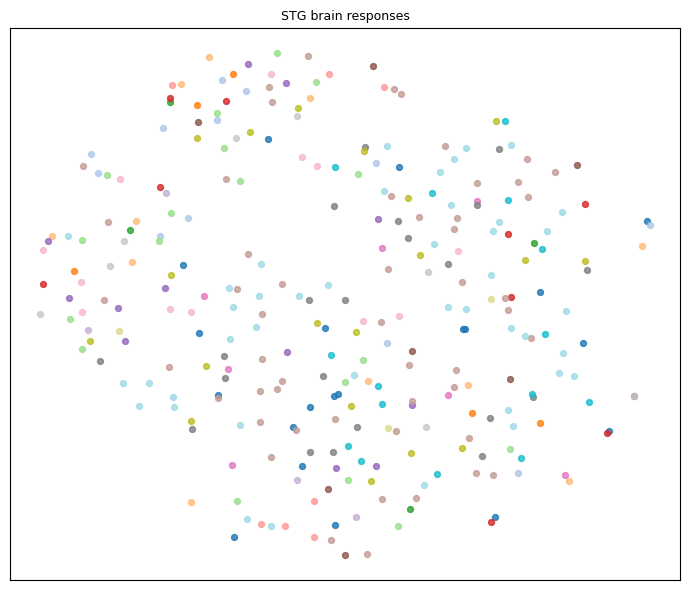

In [18]:
# T-SNE: BRAIN

# create a standalone figure for the stg t-sne embedding.
plt.figure(figsize=(7, 6))
ax = plt.gca()

# compute and plot the stg embedding with points grouped by sound category.
brain_tsne = plot_tsne(ax, brain_activations, categories, "STG brain responses")


plt.tight_layout()
plt.show()


t-SNE representative for waveform: run 0


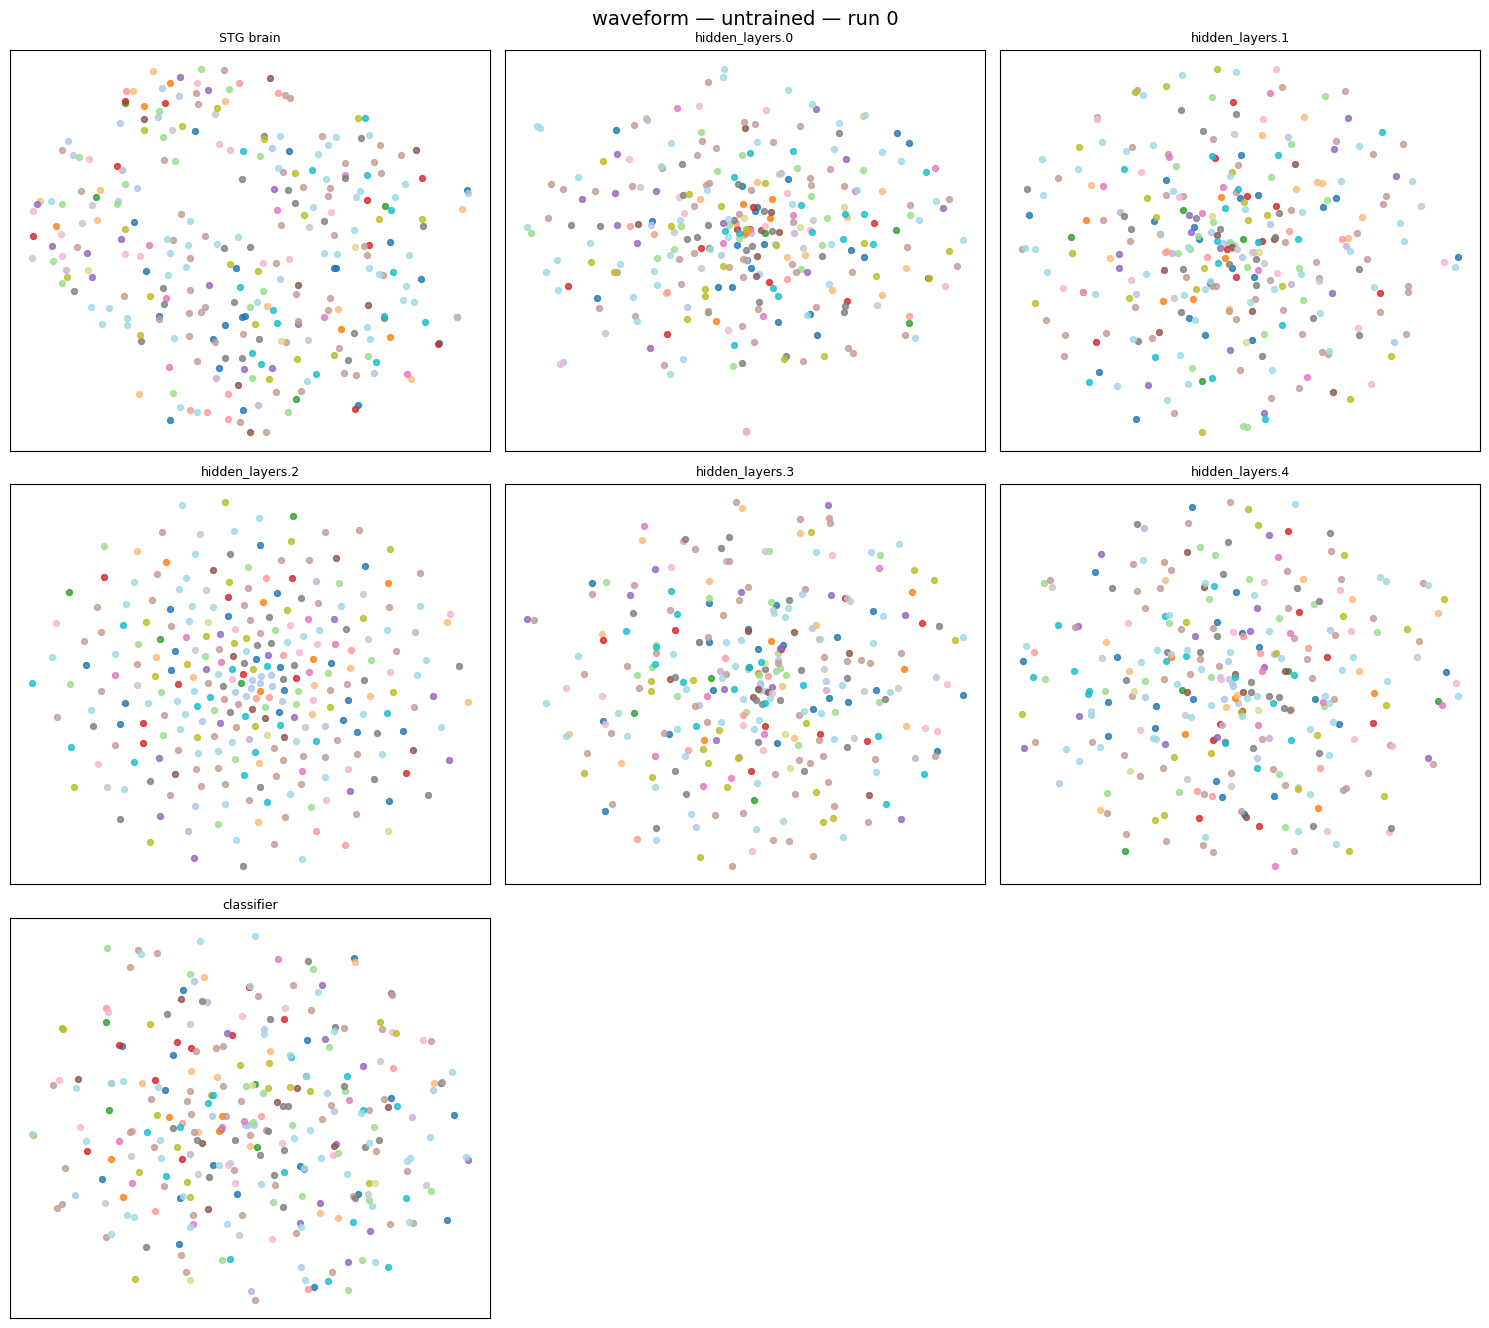

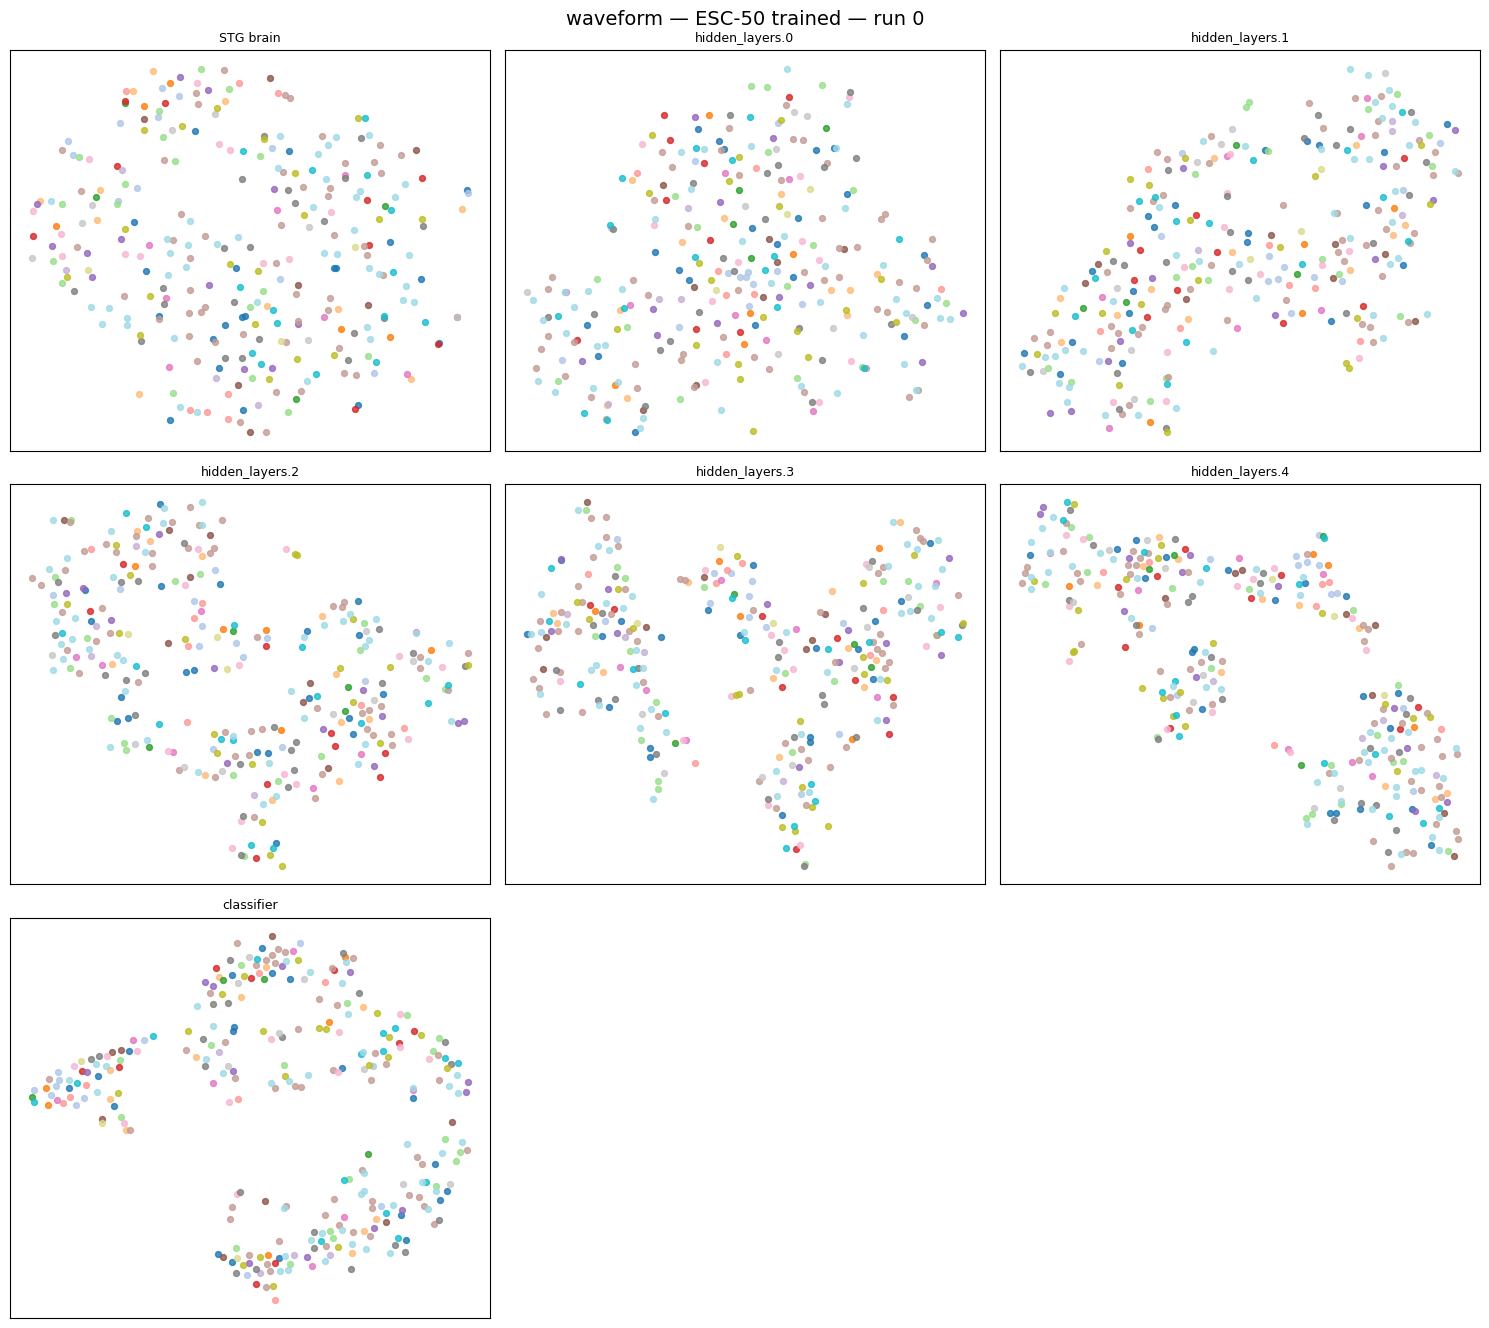

t-SNE representative for uninspired: run 0


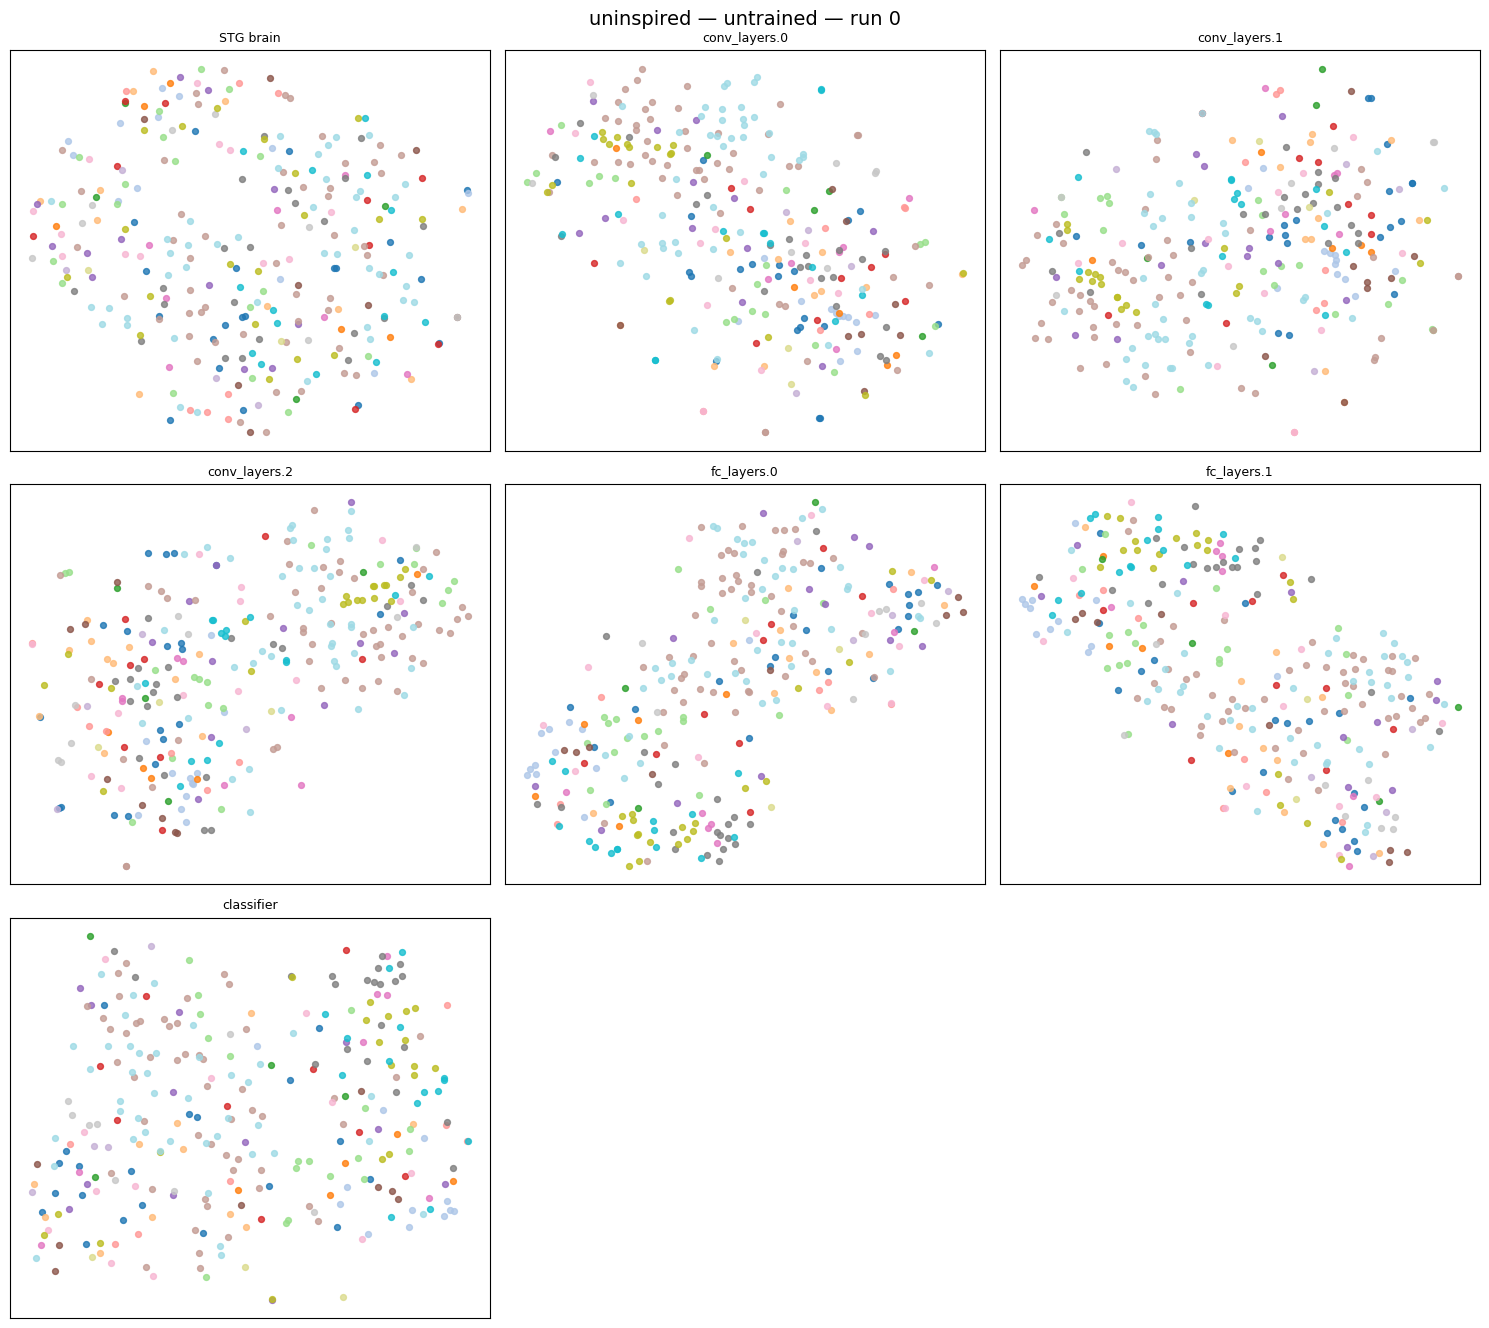

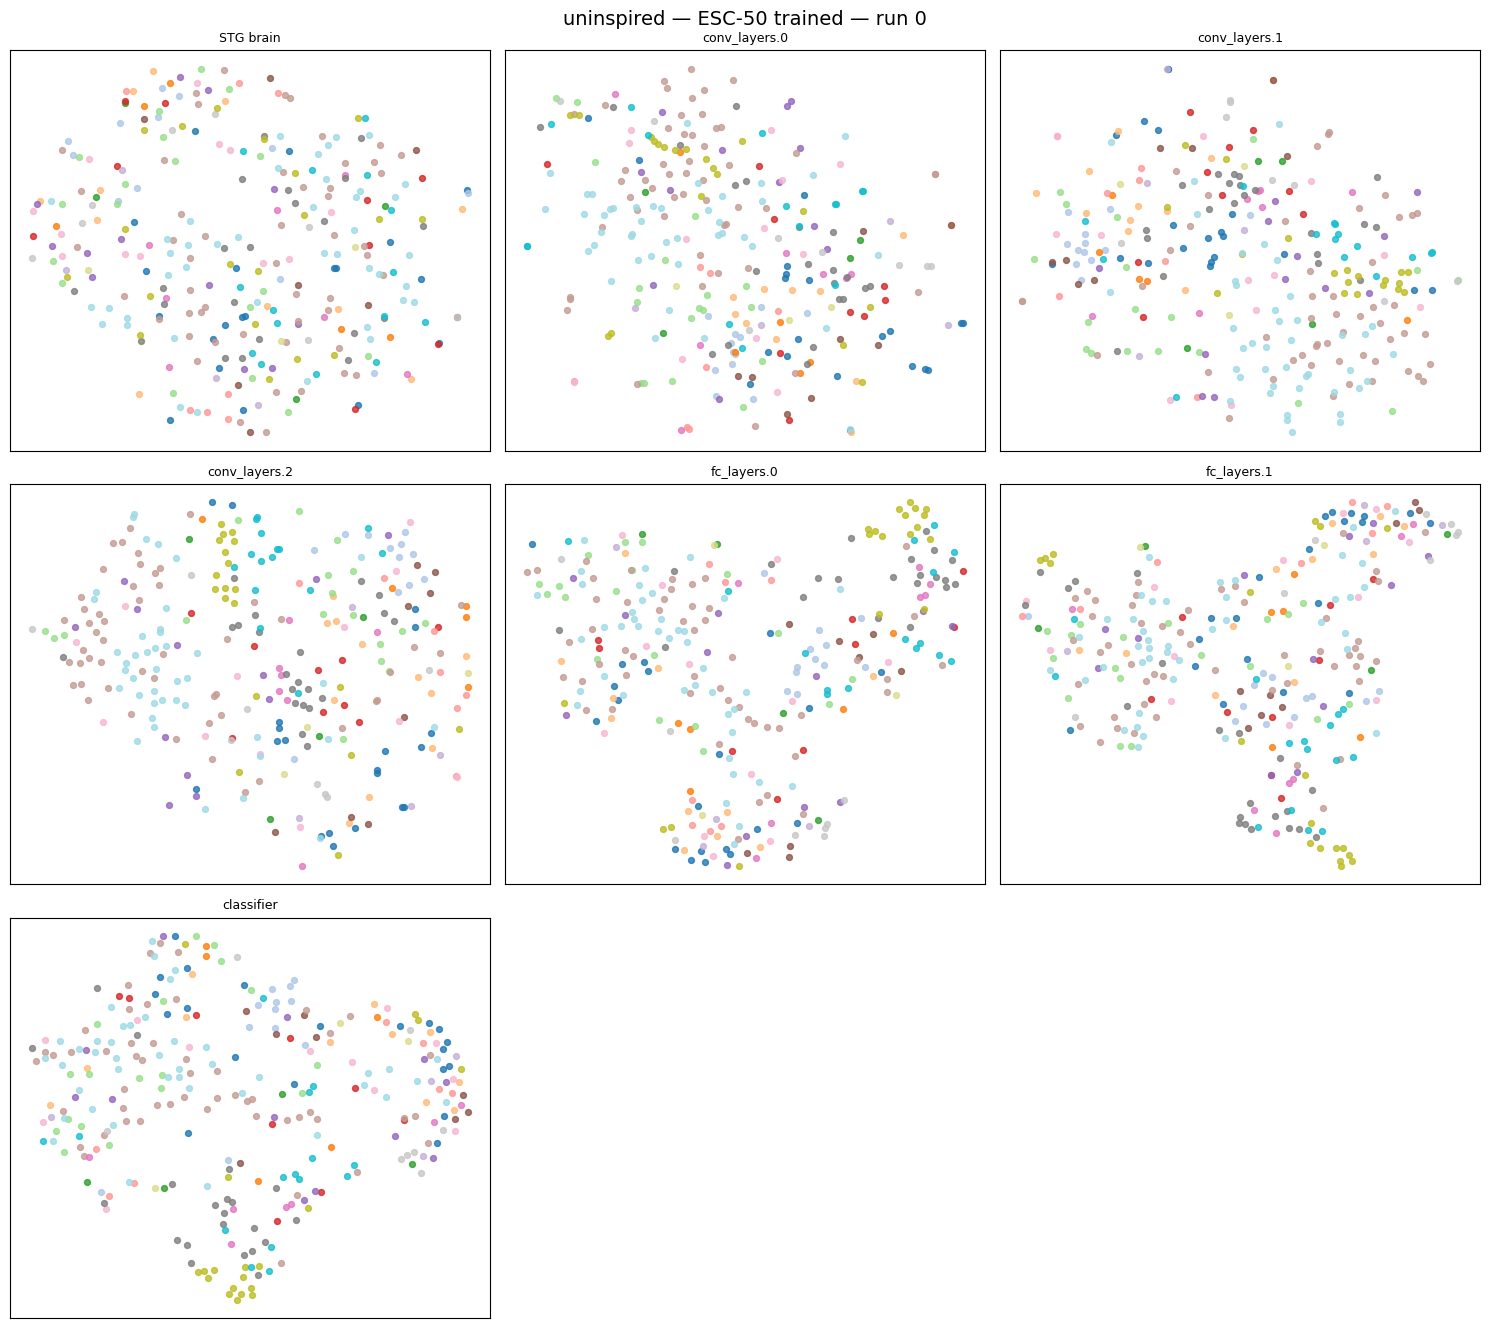

t-SNE representative for inspired: run 0


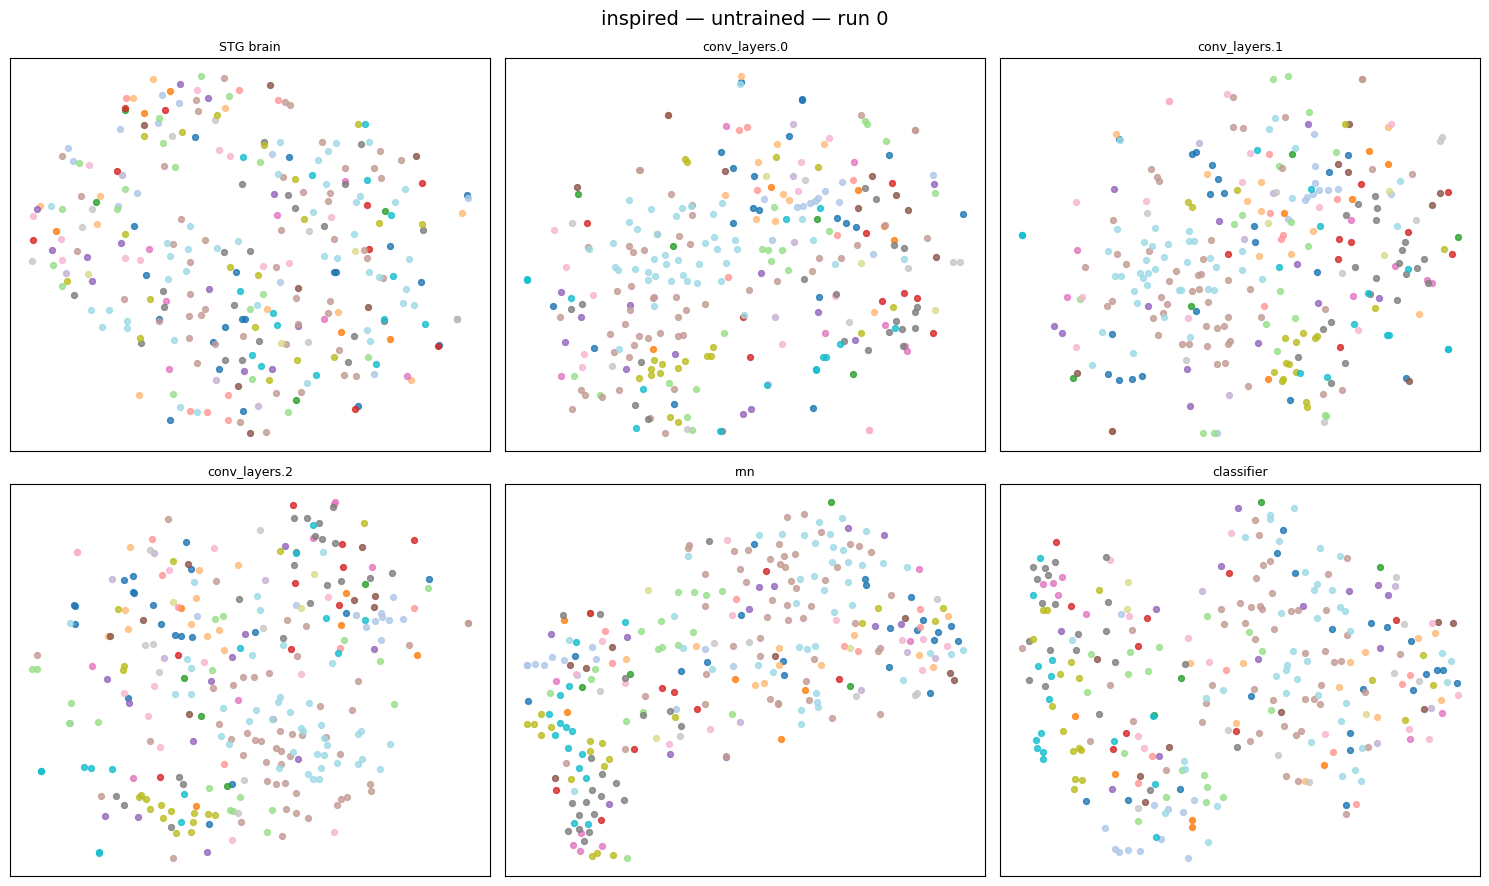

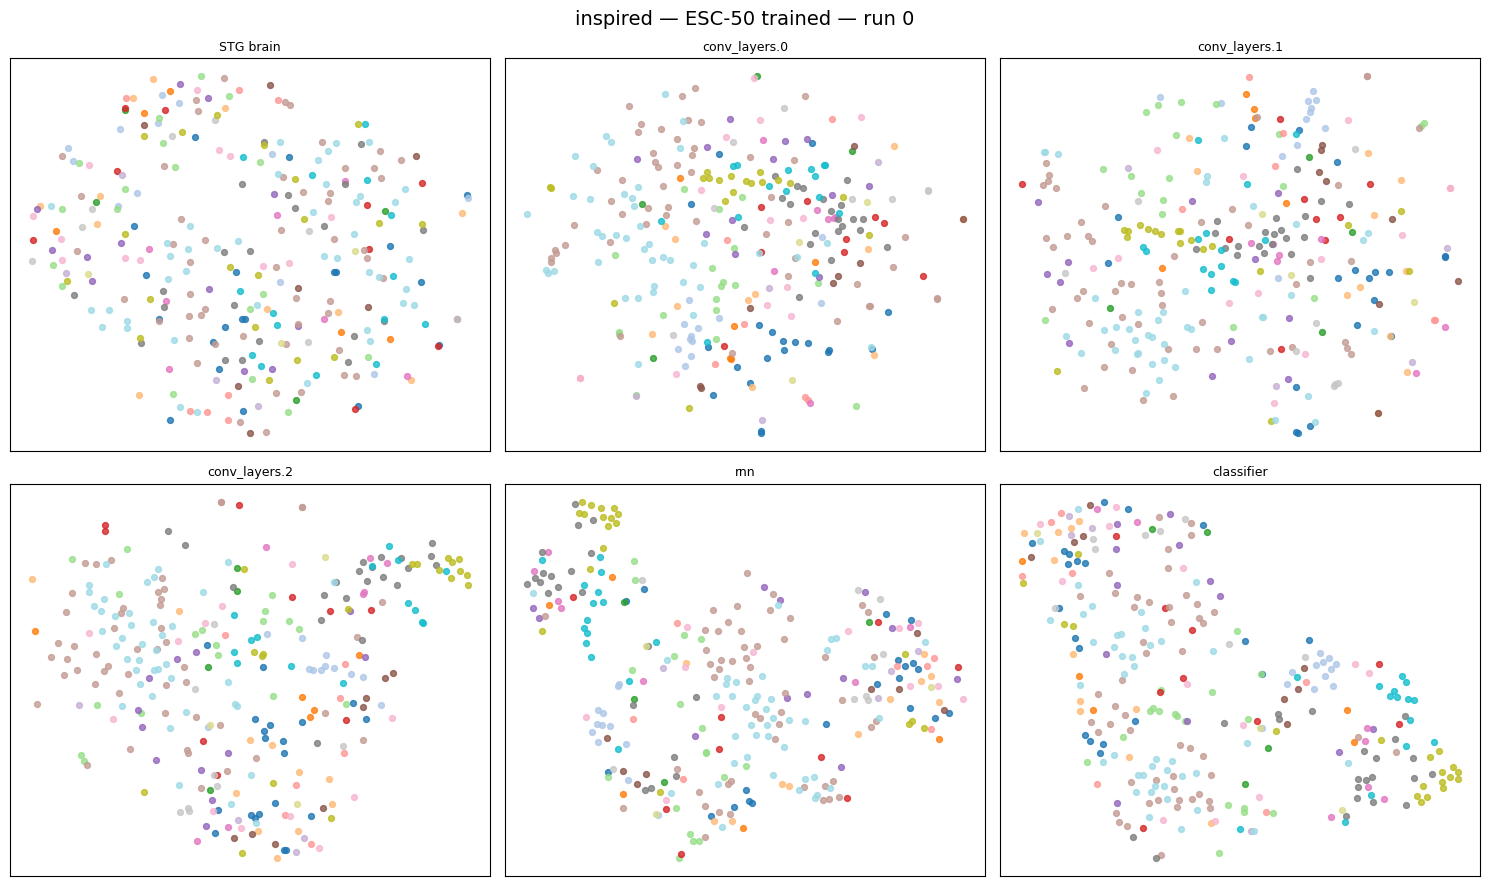

t-SNE representative for cortical_crnn: run 0


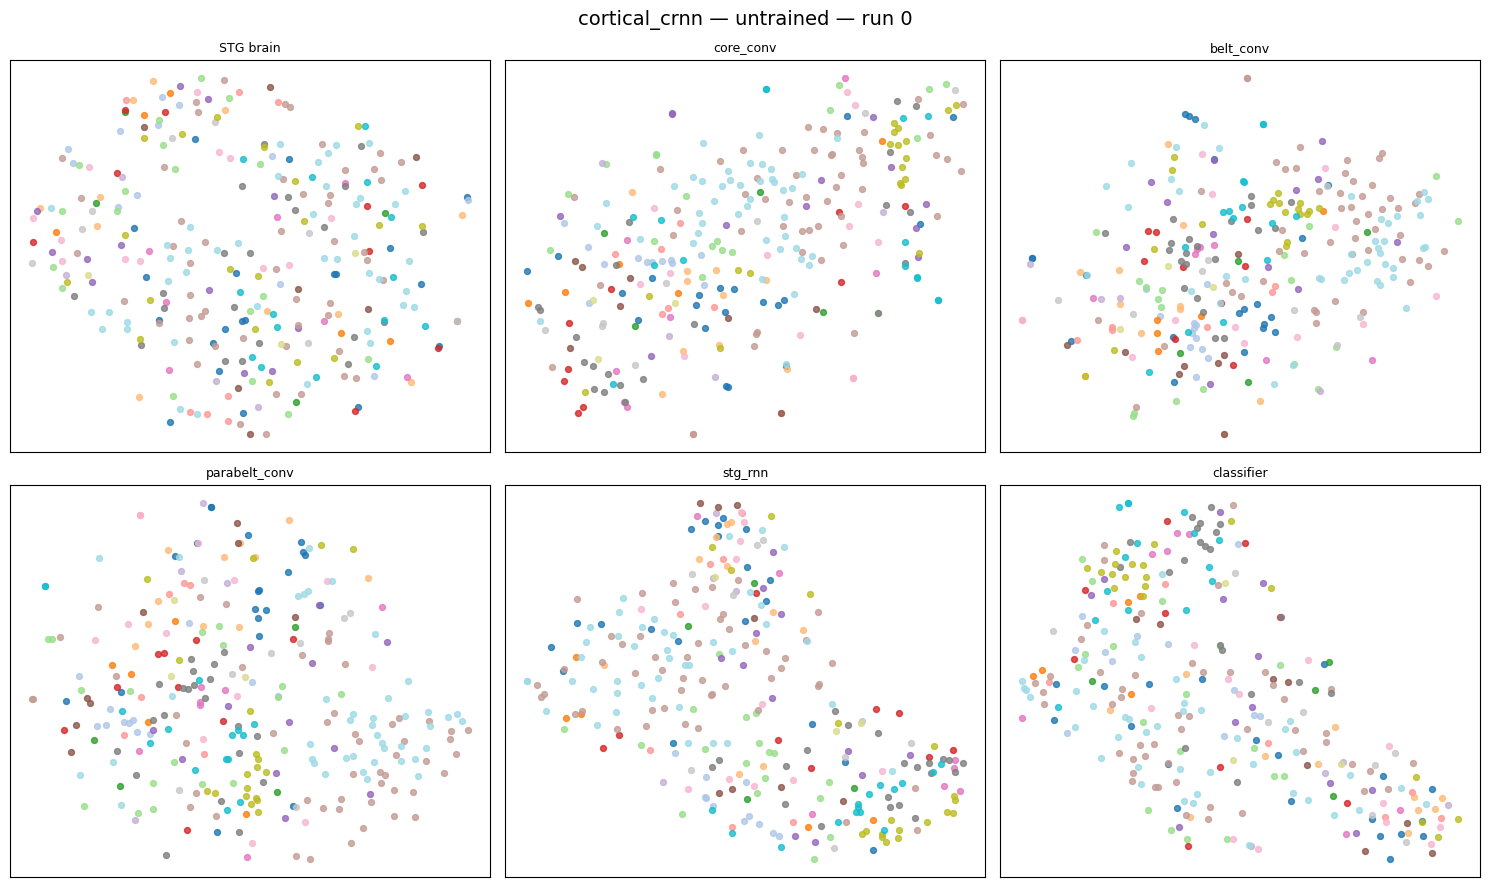

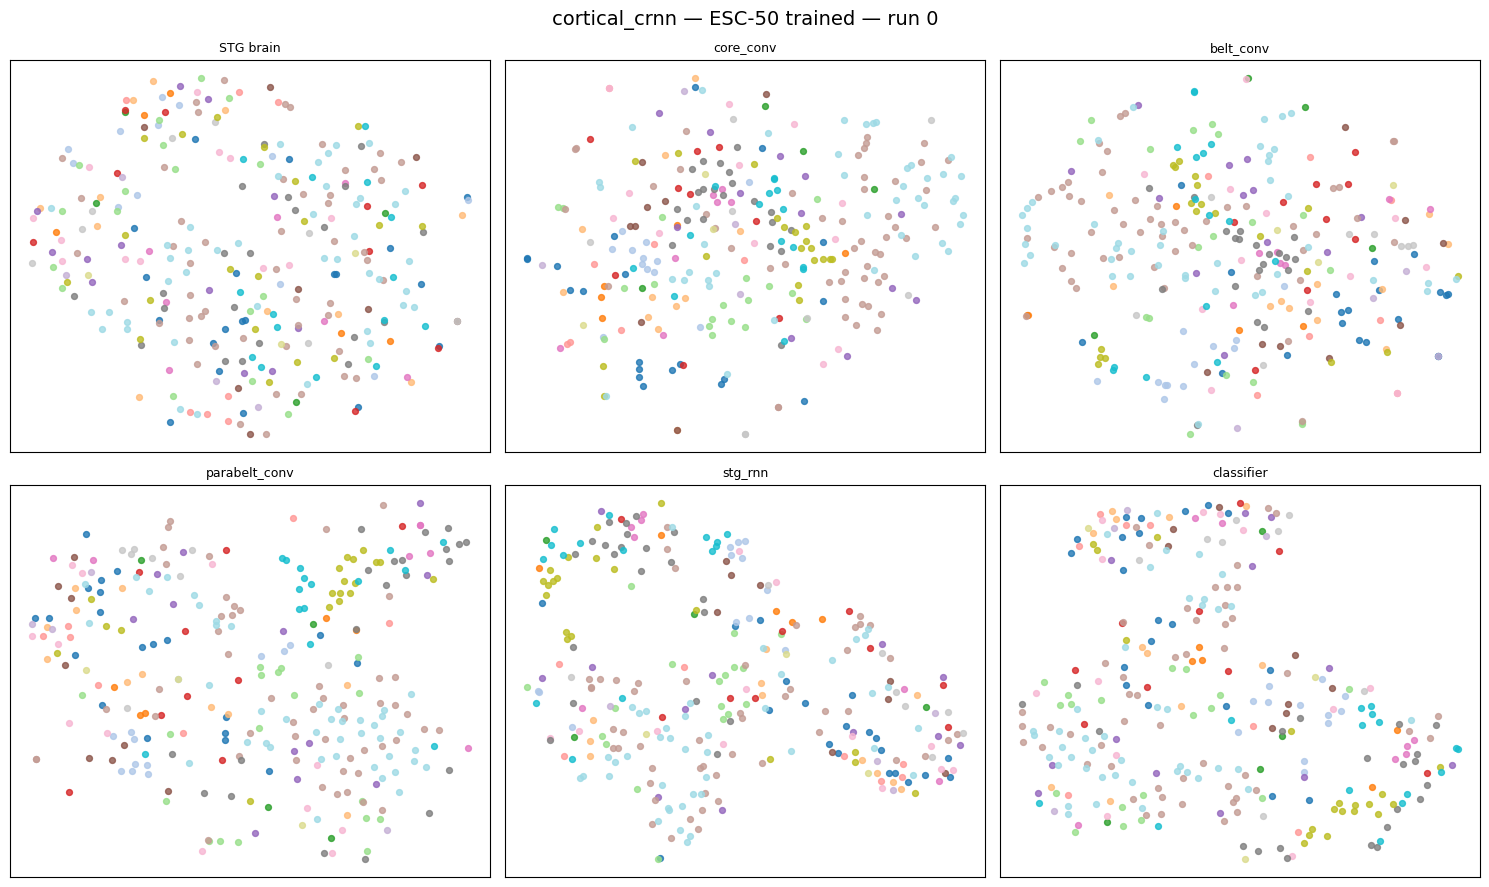

In [19]:
# T-SNE: ONE REPRESENTATIVE RUN PER MODEL: matters in case of custon corticalCRNN


# use the lowest available run id as the representative run for each model.
for model_name in provided_models:

    run_ids = sorted(trained_activations[model_name].keys())
    representative_run = run_ids[0]

    # report which run is used for the qualitative t-sne visualization.
    print(f"t-SNE representative for {model_name}: run {representative_run}")

    # plot all layers from the representative untrained model.
    plot_model_layers_tsne(
        model_name=model_name,
        activations=untrained_activations[model_name][representative_run],
        condition="untrained",
        categories=categories,
        brain_activations=brain_activations,
        run_id=representative_run,
    )

    # plot all layers from the matching esc-50-trained model.
    plot_model_layers_tsne(
        model_name=model_name,
        activations=trained_activations[model_name][representative_run],
        condition="ESC-50 trained",
        categories=categories,
        brain_activations=brain_activations,
        run_id=representative_run,
    )


## t-SNE visualization of representational structure

The t-SNE plots give a visual overview of how the sound representations change across layers. Each point represents one sound, and the colors show the sound categories. These plots should be interpreted carefully. t-SNE is useful for showing nearby groups and possible clusters, but the exact distances and shapes in the 2D plot should not be treated as precise measurements. The RSA and silhouette analyses are therefore more important for the quantitative conclusions.

### STG representation

The STG t-SNE plot shows a broad and mixed distribution rather than clearly separated category groups. Sounds from different categories overlap strongly, although some small local groups can still be seen.

This matches the negative STG silhouette score of −0.202. Both the plot and the silhouette score therefore suggest that STG does not organize the sounds into clear, compact groups based on their sound-source labels.

### Inspired model before training

In the untrained Inspired model, the early convolutional layers already change the way the sounds are arranged. The plots look different from `conv_layers.0` to `conv_layers.2`, even though the network has not yet been trained.

However, the colors remain strongly mixed, so there is little clear separation between sound categories. The recurrent and classifier stages create more visible structure, but this structure still does not form clean category groups.

This shows that an untrained network can already create organized-looking patterns simply because of its architecture and nonlinear operations. A structured t-SNE plot therefore does not automatically mean that the model has learned something useful.

### Inspired model after ESC-50 training

After training, the Inspired model shows a clearer change in organization, especially in the middle convolutional layers. Around `conv_layers.2`, several local groups become more visible. The recurrent and classifier stages then form larger branches or regions. Some categories appear more often in certain areas, suggesting that training has made category information more organized, although there is still a lot of overlap.

This fits with the RSA results, where training had its strongest positive effect in the middle convolutional layers.

However, the stronger visual separation seen in the recurrent and classifier stages does not mean that these layers match STG better. The RSA results showed that the largest improvement in brain alignment happened earlier, in the convolutional layers.

### CorticalCRNN after training

The trained CorticalCRNN shows a gradual change from `core_conv` through `parabelt_conv`, followed by a stronger change at `stg_rnn` and the classifier.

The `core_conv` and `belt_conv` plots remain fairly mixed, with strong overlap between categories. By `parabelt_conv`, the representation becomes more organized, with more visible groups and branches. This agrees with the RSA results, where `parabelt_conv` was the layer that most often showed the strongest brain alignment after training.

The `stg_rnn` and classifier plots look even more strongly divided into different regions. However, sounds from different categories are still mixed within those regions. The clear shapes in the t-SNE plot therefore should not be interpreted as clean category separation.

This also matches the silhouette results. The silhouette scores became more negative at `stg_rnn` and the classifier, even though the t-SNE plots looked more structured. In other words, visually clear groups in the 2D plot do not necessarily match the actual sound categories.

### Comparison with STG

The model t-SNE plots do not look the same as the STG plot. This is not surprising, because each t-SNE plot is created separately and can have a different overall shape.

A more useful comparison is whether the representations are generally mixed or strongly separated. The STG plot is quite mixed, with a lot of overlap between categories. The early and middle model layers also show substantial mixing, while some later layers develop clearer branches and regions.

For CorticalCRNN, `parabelt_conv` appears to lie between these two extremes. It is more organized than the early convolutional layers, but less strongly divided than the recurrent and classifier stages. This agrees with the RSA results, which showed that `parabelt_conv` was most often the best-matching layer after training.


The t-SNE results suggest that training changes the way sounds are represented across the network, but it does not simply make the sound categories more clearly separated. The results show that three things should be kept separate:

- how organized the t-SNE plot looks
- how well sound categories are separated
- how similar the model representation is to STG

These measures are related, but they do not show exactly the same thing. In this analysis, the layers that look most clearly separated in t-SNE are not always the layers that best match the brain. Overall, the intermediate convolutional layers, especially `parabelt_conv` in CorticalCRNN, appear to be the most important part of the learned representation.

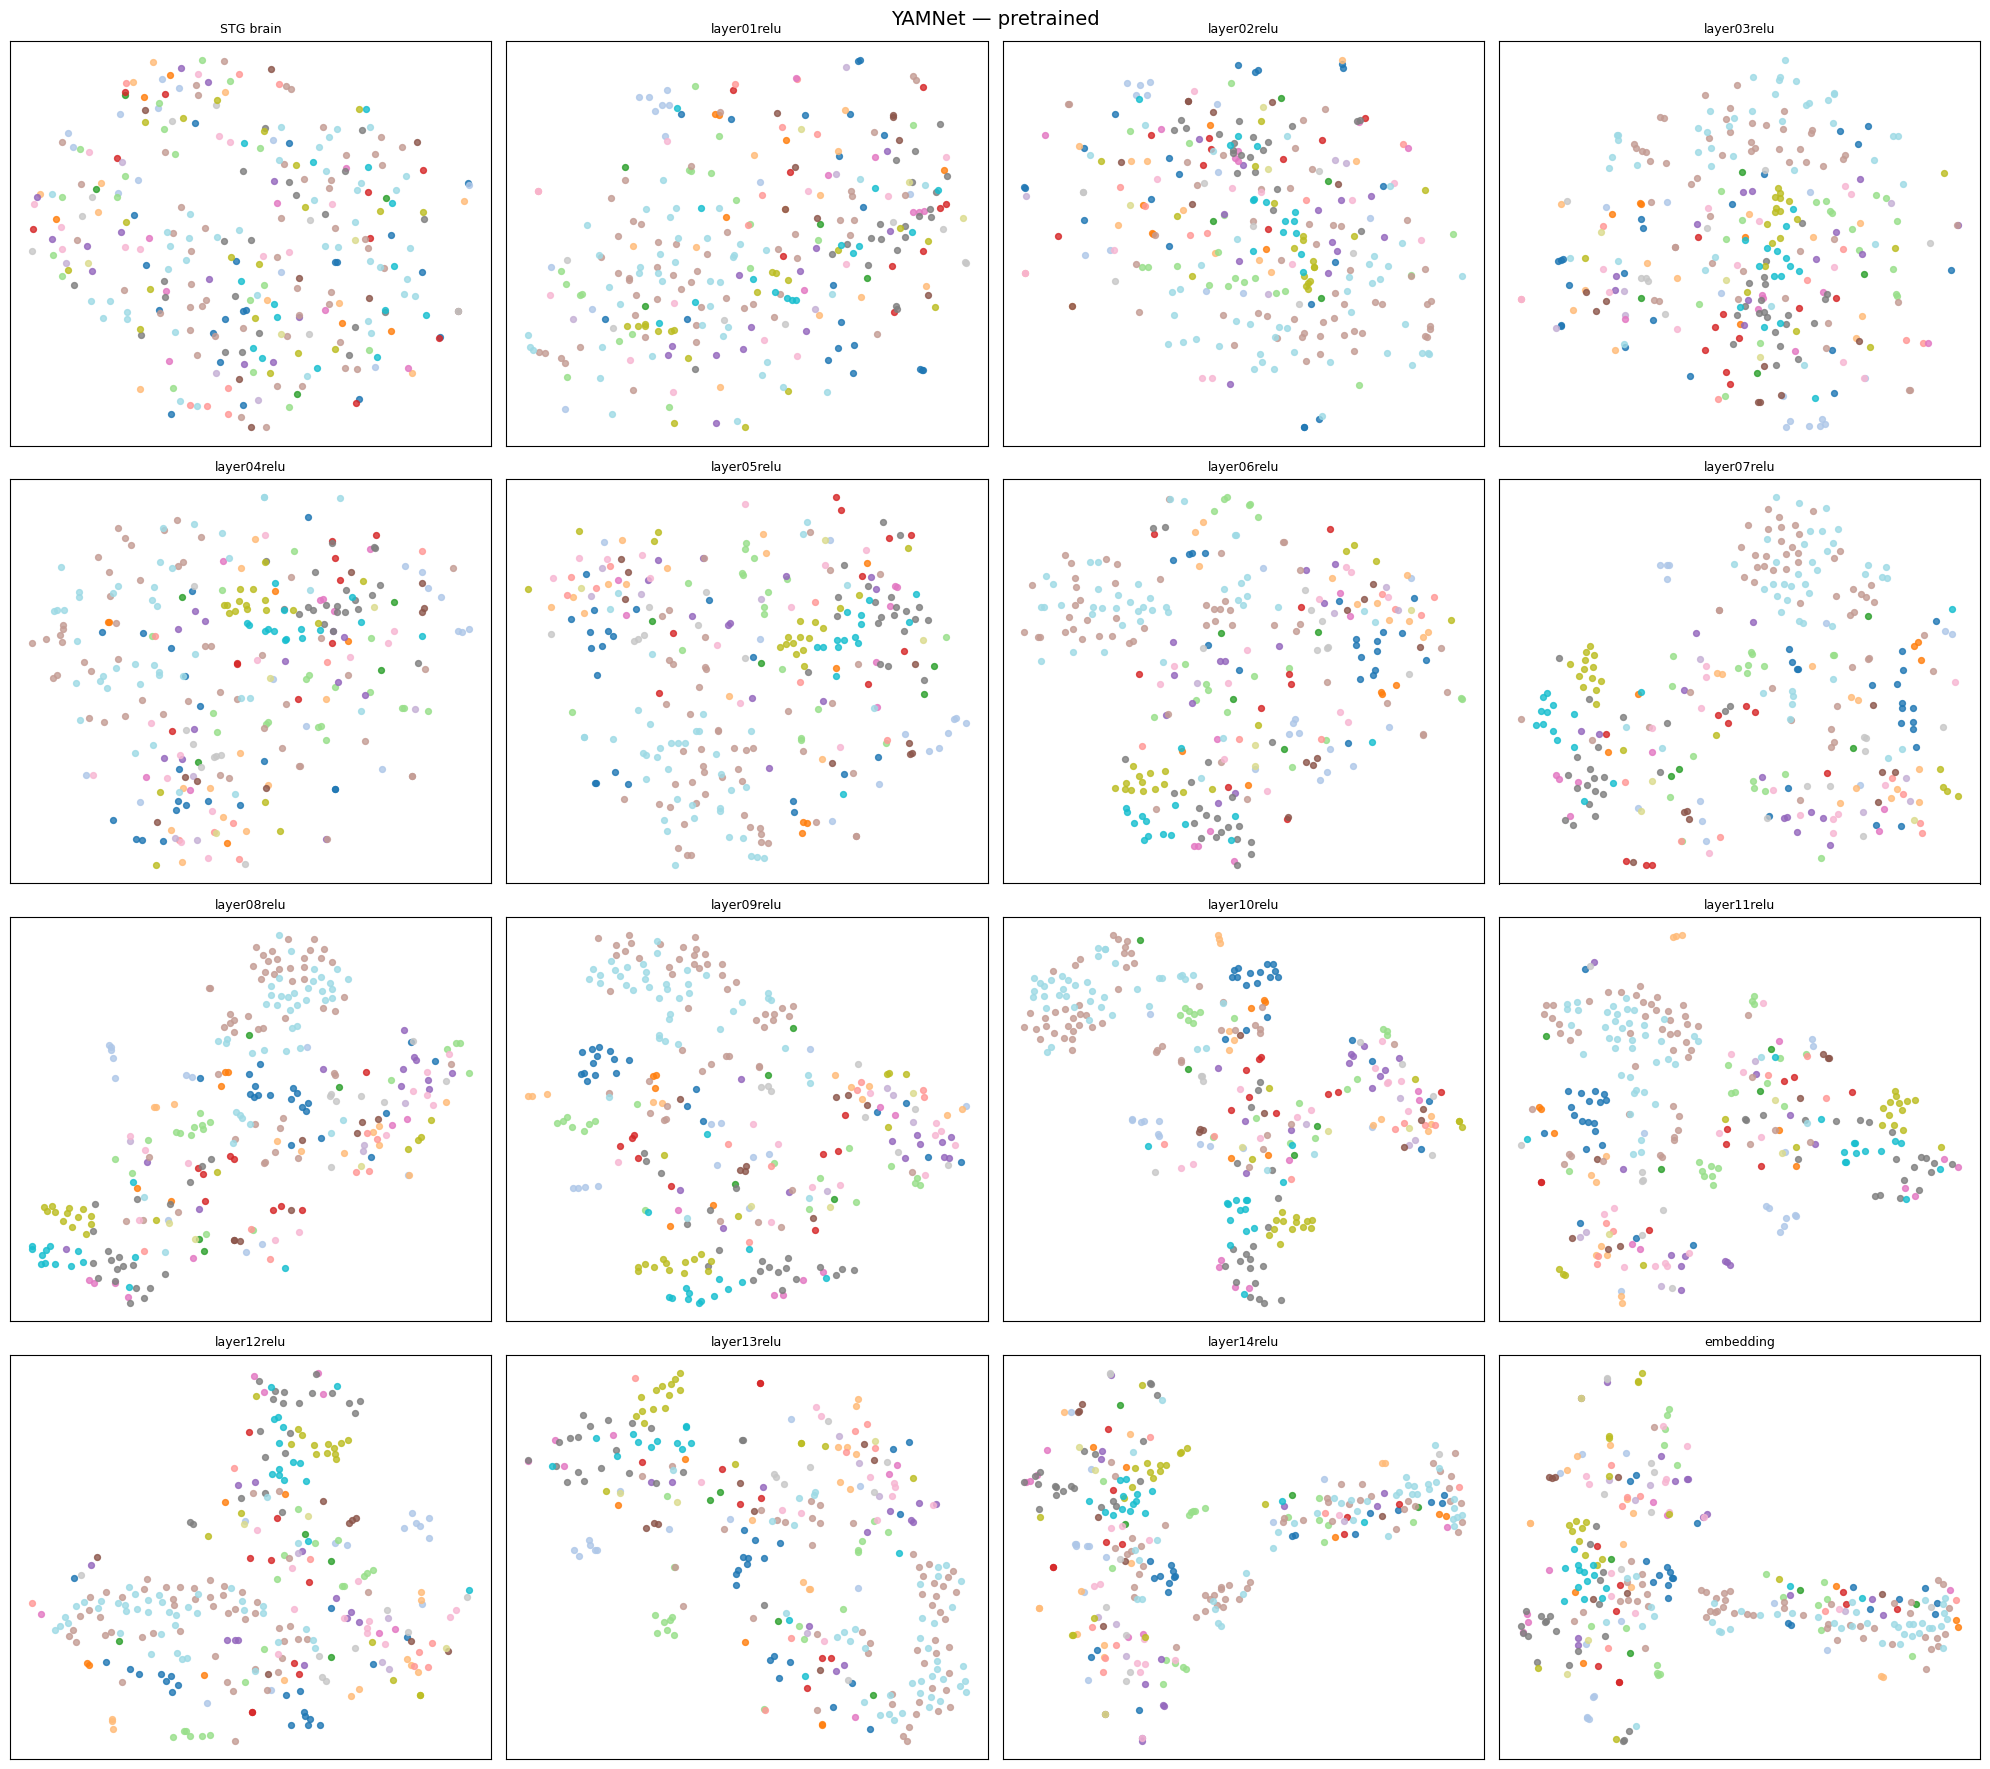


Combined RSA / category-structure results
 condition         model           layer  depth  normalized_depth   metric  rsa_mean  rsa_ci95  rsa_ci_low  rsa_ci_high  rsa_n_runs  silhouette_mean  silhouette_ci95  silhouette_ci_low  silhouette_ci_high  silhouette_n_runs
   trained cortical_crnn       core_conv      0          0.000000  kendall -0.030012  0.007956   -0.037968    -0.022056           5        -0.119629         0.009438          -0.129068           -0.110191                  5
   trained cortical_crnn       belt_conv      1          0.250000  kendall  0.012200  0.013900   -0.001700     0.026100           5        -0.126650         0.006065          -0.132715           -0.120584                  5
   trained cortical_crnn   parabelt_conv      2          0.500000  kendall  0.031760  0.011699    0.020061     0.043458           5        -0.162171         0.011003          -0.173174           -0.151168                  5
   trained cortical_crnn         stg_rnn      3          0.75

In [20]:
# T-SNE: YAMNET

# plot stg and all yamnet layers using the fixed pretrained model.
plot_model_layers_tsne(
    model_name="YAMNet",
    activations=yamnet_activations,
    condition="pretrained",
    categories=categories,
    brain_activations=brain_activations,
    ncols=4,
)


# COMBINED RSA + CATEGORY STRUCTURE TABLE


# rename rsa summary columns before merging them with category separability results.
rsa_summary_for_merge = rsa_df.rename(columns={
    "mean": "rsa_mean",
    "ci95": "rsa_ci95",
    "ci_low": "rsa_ci_low",
    "ci_high": "rsa_ci_high",
    "n_runs": "rsa_n_runs",
})

# same with separability columns before merging them with rsa results.
category_summary_for_merge = category_separability_df.rename(columns={
    "mean": "silhouette_mean",
    "ci95": "silhouette_ci95",
    "ci_low": "silhouette_ci_low",
    "ci_high": "silhouette_ci_high",
    "n_runs": "silhouette_n_runs",
})

# merge rsa and category structure statistics for matching model layers.
summary_df = rsa_summary_for_merge.merge(
    category_summary_for_merge[
        [
            "condition",
            "model",
            "layer",
            "silhouette_mean",
            "silhouette_ci95",
            "silhouette_ci_low",
            "silhouette_ci_high",
            "silhouette_n_runs",
        ]
    ],
    on=["condition", "model", "layer"],
    how="left",
).sort_values(["metric", "model", "condition", "depth"])


print("\nCombined RSA / category-structure results")
print(summary_df.to_string(index=False))

In [21]:
# RELATIONSHIP BETWEEN CATEGORY STRUCTURE AND BRAIN ALIGNMENT

# merge run-level rsa values with category separability scores for matching model layers.
raw_summary_df = rsa_run_df.merge(
    category_run_df[["condition", "model", "run", "layer", "silhouette"]],
    on=["condition", "model", "run", "layer"],
    how="left",
)

# store one correlation per independent model run and rsa metric.
category_alignment_rows = []

# measure the relationship between category separability and brain alignment across layers.
for (condition, model_name, run_id, metric), group in raw_summary_df.groupby(["condition", "model", "run", "metric"], sort=False):

    # keep only layers with valid brain alignment and silhouette values.
    group = group.dropna(subset=["brain_alignment", "silhouette"])

    # skip runs with too few valid layers for a meaningful correlation.
    if len(group) < 3:
        continue

    # compute spearman correlation between category separability and stg alignment.
    rho, p_value = spearmanr(group["silhouette"], group["brain_alignment"])

    # store the run-level correlation and corresponding p-value.
    category_alignment_rows.append({
        "condition": condition,
        "model": model_name,
        "run": run_id,
        "metric": metric,
        "rho_category_vs_brain_alignment": rho,
        "p_value": p_value,
        "n_layers": len(group),
    })

# convert run-level correlation results to a dataframe.
category_alignment_run_df = pd.DataFrame(category_alignment_rows)

# summarize correlations across runs using the mean and 95% confidence interval.
category_alignment_df = summarize_with_ci(
    category_alignment_run_df,
    group_columns=["condition", "model", "metric"],
    value_column="rho_category_vs_brain_alignment",
)

print("\nRelationship between category separability and STG alignment")
print(category_alignment_df.sort_values(["metric", "condition", "model"]).to_string(index=False))



Relationship between category separability and STG alignment
 condition         model   metric      mean     ci95    ci_low   ci_high  n_runs
pretrained        yamnet  kendall  0.110714      NaN       NaN       NaN       1
   trained cortical_crnn  kendall -0.360000 0.319666 -0.679666 -0.040334       5
   trained      inspired  kendall -0.820000 0.144030 -0.964030 -0.675970       5
   trained    uninspired  kendall -0.657143 0.093706 -0.750849 -0.563437       5
   trained      waveform  kendall -0.291429 0.404753 -0.696181  0.113324       5
 untrained cortical_crnn  kendall -0.560000 0.274400 -0.834400 -0.285600       5
 untrained      inspired  kendall -0.660000 0.048010 -0.708010 -0.611990       5
 untrained    uninspired  kendall -0.748571 0.139888 -0.888459 -0.608683       5
 untrained      waveform  kendall -0.565714 0.309979 -0.875693 -0.255735       5
pretrained        yamnet  pearson  0.357143      NaN       NaN       NaN       1
   trained cortical_crnn  pearson -0.080000 0.4

In [ ]:
# COMPACT TABLE REPRESENTATION


# select the main layer-level statistics used for reporting.
final_columns = [
    "condition",
    "model",
    "layer",
    "metric",
    "rsa_mean",
    "rsa_ci95",
    "rsa_ci_low",
    "rsa_ci_high",
    "rsa_n_runs",
    "silhouette_mean",
    "silhouette_ci95",
]

# create a compact copy of the final layer-level results.
final_results_df = summary_df[final_columns].copy()

# report the compact layer-level results table.
print("\nFINAL LAYER-LEVEL RESULTS")
print(final_results_df.to_string(index=False))





FINAL LAYER-LEVEL RESULTS
 condition         model           layer   metric  rsa_mean  rsa_ci95  rsa_ci_low  rsa_ci_high  rsa_n_runs  silhouette_mean  silhouette_ci95
   trained cortical_crnn       core_conv  kendall -0.030012  0.007956   -0.037968    -0.022056           5        -0.119629         0.009438
   trained cortical_crnn       belt_conv  kendall  0.012200  0.013900   -0.001700     0.026100           5        -0.126650         0.006065
   trained cortical_crnn   parabelt_conv  kendall  0.031760  0.011699    0.020061     0.043458           5        -0.162171         0.011003
   trained cortical_crnn         stg_rnn  kendall  0.014464  0.016678   -0.002214     0.031142           5        -0.357013         0.025960
   trained cortical_crnn      classifier  kendall  0.012565  0.012787   -0.000222     0.025352           5        -0.488422         0.024117
 untrained cortical_crnn       core_conv  kendall -0.035805  0.009604   -0.045409    -0.026200           5        -0.176331    

## Summary table

Across the three RSA measures—Pearson, Spearman, and Kendall’s tau-b—the main patterns were broadly consistent. Overall RSA values were small, indicating that none of the tested models reproduced the STG representational structure closely. The results are therefore most useful for comparing relative differences between architectures and layers rather than claiming that any model provides a close model of STG processing. The five independently trained runs also showed that some effects were more stable than others, as reflected by the 95% confidence intervals. 

The waveform model showed the weakest overall correspondence with STG. RSA values remained negative throughout the trained network for all three comparison measures. Training also produced much more negative silhouette scores, reaching approximately −0.79 in the classifier. This suggests that learning directly from the raw waveform substantially changed the representation, but did not make it either more brain-like or more clearly organized according to the sound-source labels. 

The uninspired model showed a gradual change from negative RSA in the first convolutional layers to small positive values in the later layers. However, the untrained model often showed equal or stronger positive alignment in the fully connected layers, suggesting that training did not simply improve STG similarity across the whole network. Its convolutional layers showed relatively good category separation, whereas category structure became much weaker once the representation entered the fully connected layers. 

The inspired model showed a clearer increase in brain alignment across its convolutional hierarchy. After training, the third convolutional layer, recurrent layer, and classifier all had positive RSA values, with Spearman correlations around 0.045–0.055. Training particularly improved the middle convolutional representations. At the same time, the untrained recurrent and classifier layers already showed relatively strong positive RSA, so training did not improve every stage. Category separation was generally better after training, especially in the convolutional layers, but became weaker in the recurrent and classifier stages. 

The CorticalCRNN showed one of the clearest training-related changes in where brain alignment appeared. Before training, the early convolutional stages showed negative RSA, while the strongest alignment occurred at the recurrent `stg_rnn` stage. After ESC-50 training, alignment improved through `belt_conv` and reached its strongest value at `parabelt_conv`—for example, Spearman RSA was about 0.047 with a 95% CI of approximately 0.030–0.065. Alignment then decreased again at `stg_rnn` and the classifier. This suggests that training reorganized the hierarchy rather than uniformly increasing brain similarity, shifting the strongest STG correspondence from the recurrent stage toward the intermediate cortical-inspired convolutional stages.

The category analysis supported this interpretation only partly. The early and intermediate convolutional layers of the Inspired, Uninspired, and CorticalCRNN models generally showed better separation of the sound-source labels than their later recurrent or fully connected stages. For CorticalCRNN, for example, silhouette scores were around −0.12 to −0.16 across the convolutional hierarchy but dropped to about −0.36 at `stg_rnn` and −0.49 at the classifier. This shows that stronger category organization and stronger STG alignment are not the same thing: a layer can separate labels reasonably well without closely matching the full structure of the brain responses.

YAMNet provided a useful pretrained reference. Some intermediate and later layers showed stronger STG correspondence than most layers of the custom models—for example, Spearman RSA reached about 0.098 at `layer12relu. However, the layer giving the strongest result depended somewhat on the RSA metric; Pearson, for instance, was highest around layers 8–9. Because only one pretrained YAMNet instance was available, these values have no across-run confidence intervals and should be treated as descriptive rather than statistically equivalent to the five-run model estimates. 

Overall, the results suggest that intermediate convolutional representations are particularly important. ESC-50 training often improved the organization and STG correspondence of these stages, especially in the Inspired model and CorticalCRNN. Later recurrent or classifier stages produced more task-specific representations, but these were not consistently more similar to STG and often showed poorer category separation. The strongest conclusion is therefore not that one architecture fully matches auditory cortex, but that the location and type of processing within the network strongly influence how brain-like its internal representations become.

## Challenges and sources/docs used: 

- The most challenging coding part was probably making the analysis correctly handle multiple models, multiple runs, and multiple layers at the same time. 

- activation extraction and RSA pipeline. Different layers produce outputs with different shapes, so the code has to flatten them consistently, preserve the exact sound order, build valid 288 × 288 RDMs, and compare only the unique pairwise distances. -> Addressed with PyTorch forward hooks documentation.

- For the CorticalCRNN specifically, another challenging part was making sure the transition from convolutional processing to the GRU is dimensionally correct:
x = x.mean(dim=2).transpose(1, 2) -> PyTorch GRU documentation helpful.

- turning RDM into brain similarity score -> RSA Toolbox comparison methods

- ensuring randomness/reproducibility across 5 independently trained networks; keeping training runs reproducible -> PyTorch seeds/DataLoader docs

